In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from pathlib import Path

---

# Convergence visualization

In [17]:
# Set the path to the folder containing calculation results
# Change this to point to your results folder
# RESULTS_PATH = "data/conv_biharmonic_prod"
RESULTS_PATH = "data/conv_biharmonic_max_prod"

In [18]:
# Find all conv_history.dat files
results_path = Path(RESULTS_PATH)
conv_files = list(results_path.glob("*/conv_history.dat"))

print(f"Found {len(conv_files)} convergence history files")
for f in conv_files:
    print(f"  - {f.parent.name}")

Found 8 convergence history files
  - jacobi_diag_cuda_float_32_20260127_233154
  - gmres_mg_cuda_double_32_20260127_233207
  - gmres_diag_cuda_double_32_20260127_233204
  - jacobi_mg_cuda_double_32_20260127_233200
  - gmres_diag_cuda_float_32_20260127_233202
  - jacobi_mg_cuda_float_32_20260127_233159
  - jacobi_diag_cuda_double_32_20260127_233156
  - gmres_mg_cuda_float_32_20260127_233205


In [19]:
# Parse folder name to extract parameters
def parse_folder_name(folder_name):
    """Parse folder name like 'jacobi_diag_cuda_float_32_20260127_181708' into parameters"""
    parts = folder_name.split('_')
    if len(parts) >= 5:
        solver = parts[0].lower()
        prec = parts[1].lower()
        arch = parts[2].lower()
        dtype = parts[3].lower()  # 'float' or 'double'
        size = int(parts[4])
        return solver, prec, arch, size, dtype
    return None

# Store data in dictionary: key = (solver, prec, arch, size), value = {dtype: (iterations, residuals)}
convergence_dict = {}

for conv_file in sorted(conv_files):
    folder_name = conv_file.parent.name
    params = parse_folder_name(folder_name)

    if params is None:
        print(f"Warning: Could not parse folder name: {folder_name}")
        continue

    solver, prec, arch, size, dtype = params
    key = (solver, prec, arch, size)

    # Read data
    try:
        data = np.loadtxt(conv_file)
        if data.ndim == 1:
            # Single row case
            iterations = np.array([data[0]])
            residuals = np.array([data[1]])
        else:
            iterations = data[:, 0]
            residuals = data[:, 1]

        # Downsample if needed (every 3rd point)
        if len(iterations) > 20:
            factor = 10
        elif len(iterations) > 10:
            factor = 2
        else:
            factor = 0

        if factor != 0:
            # print('before:', iterations)
            # print(len(iterations))
            # print((len(iterations)//factor)*factor)
            idx = list(range(0, (len(iterations)//factor)*factor, factor))
            if len(iterations) % factor != 0:
                idx.append(len(iterations)-1)

            iterations_downsample = iterations[idx]
            residuals_downsample = residuals[idx]
            # residuals_downsample = residuals[:((len(residuals)//factor)*factor):factor]
        else:
            iterations_downsample = iterations.copy()
            residuals_downsample = residuals.copy()
        # iterations, residuals = downsample_data(iterations, residuals, factor=1)

        # Initialize nested dict if key doesn't exist
        if key not in convergence_dict:
            convergence_dict[key] = {}

        convergence_dict[key][dtype] = (iterations_downsample, residuals_downsample)
        print(f"Loaded: {solver} + {prec} ({arch}, {dtype}, N={size}) - {len(iterations)} points")
    except Exception as e:
        print(f"Error reading {conv_file}: {e}")

print(f"\nTotal configurations: {len(convergence_dict)}")

Loaded: gmres + diag (cuda, double, N=32) - 148 points
Loaded: gmres + diag (cuda, float, N=32) - 73 points
Loaded: gmres + mg (cuda, double, N=32) - 10 points
Loaded: gmres + mg (cuda, float, N=32) - 6 points
Loaded: jacobi + diag (cuda, double, N=32) - 4822 points
Loaded: jacobi + diag (cuda, float, N=32) - 2488 points
Loaded: jacobi + mg (cuda, double, N=32) - 18 points
Loaded: jacobi + mg (cuda, float, N=32) - 9 points

Total configurations: 4


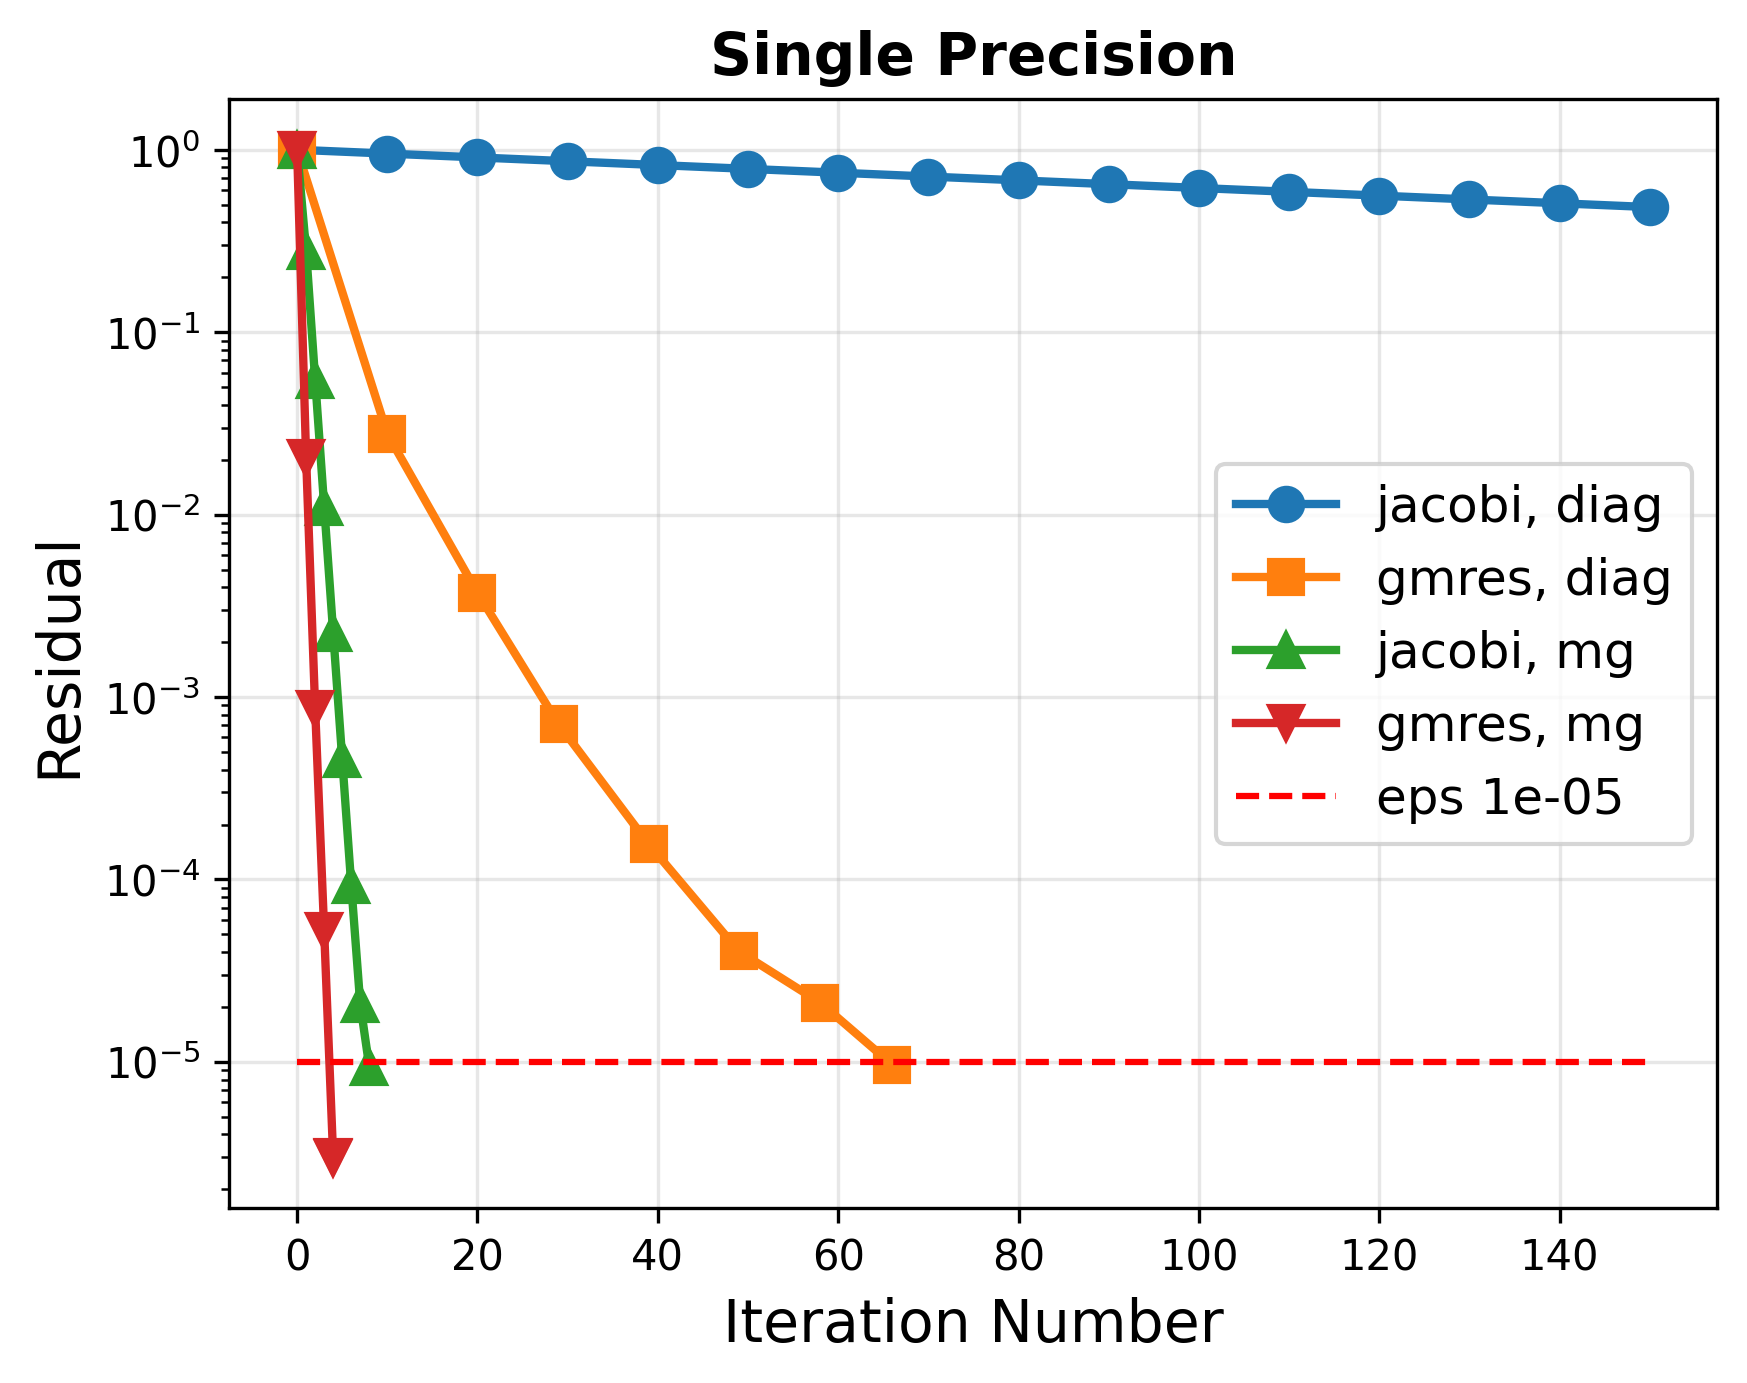

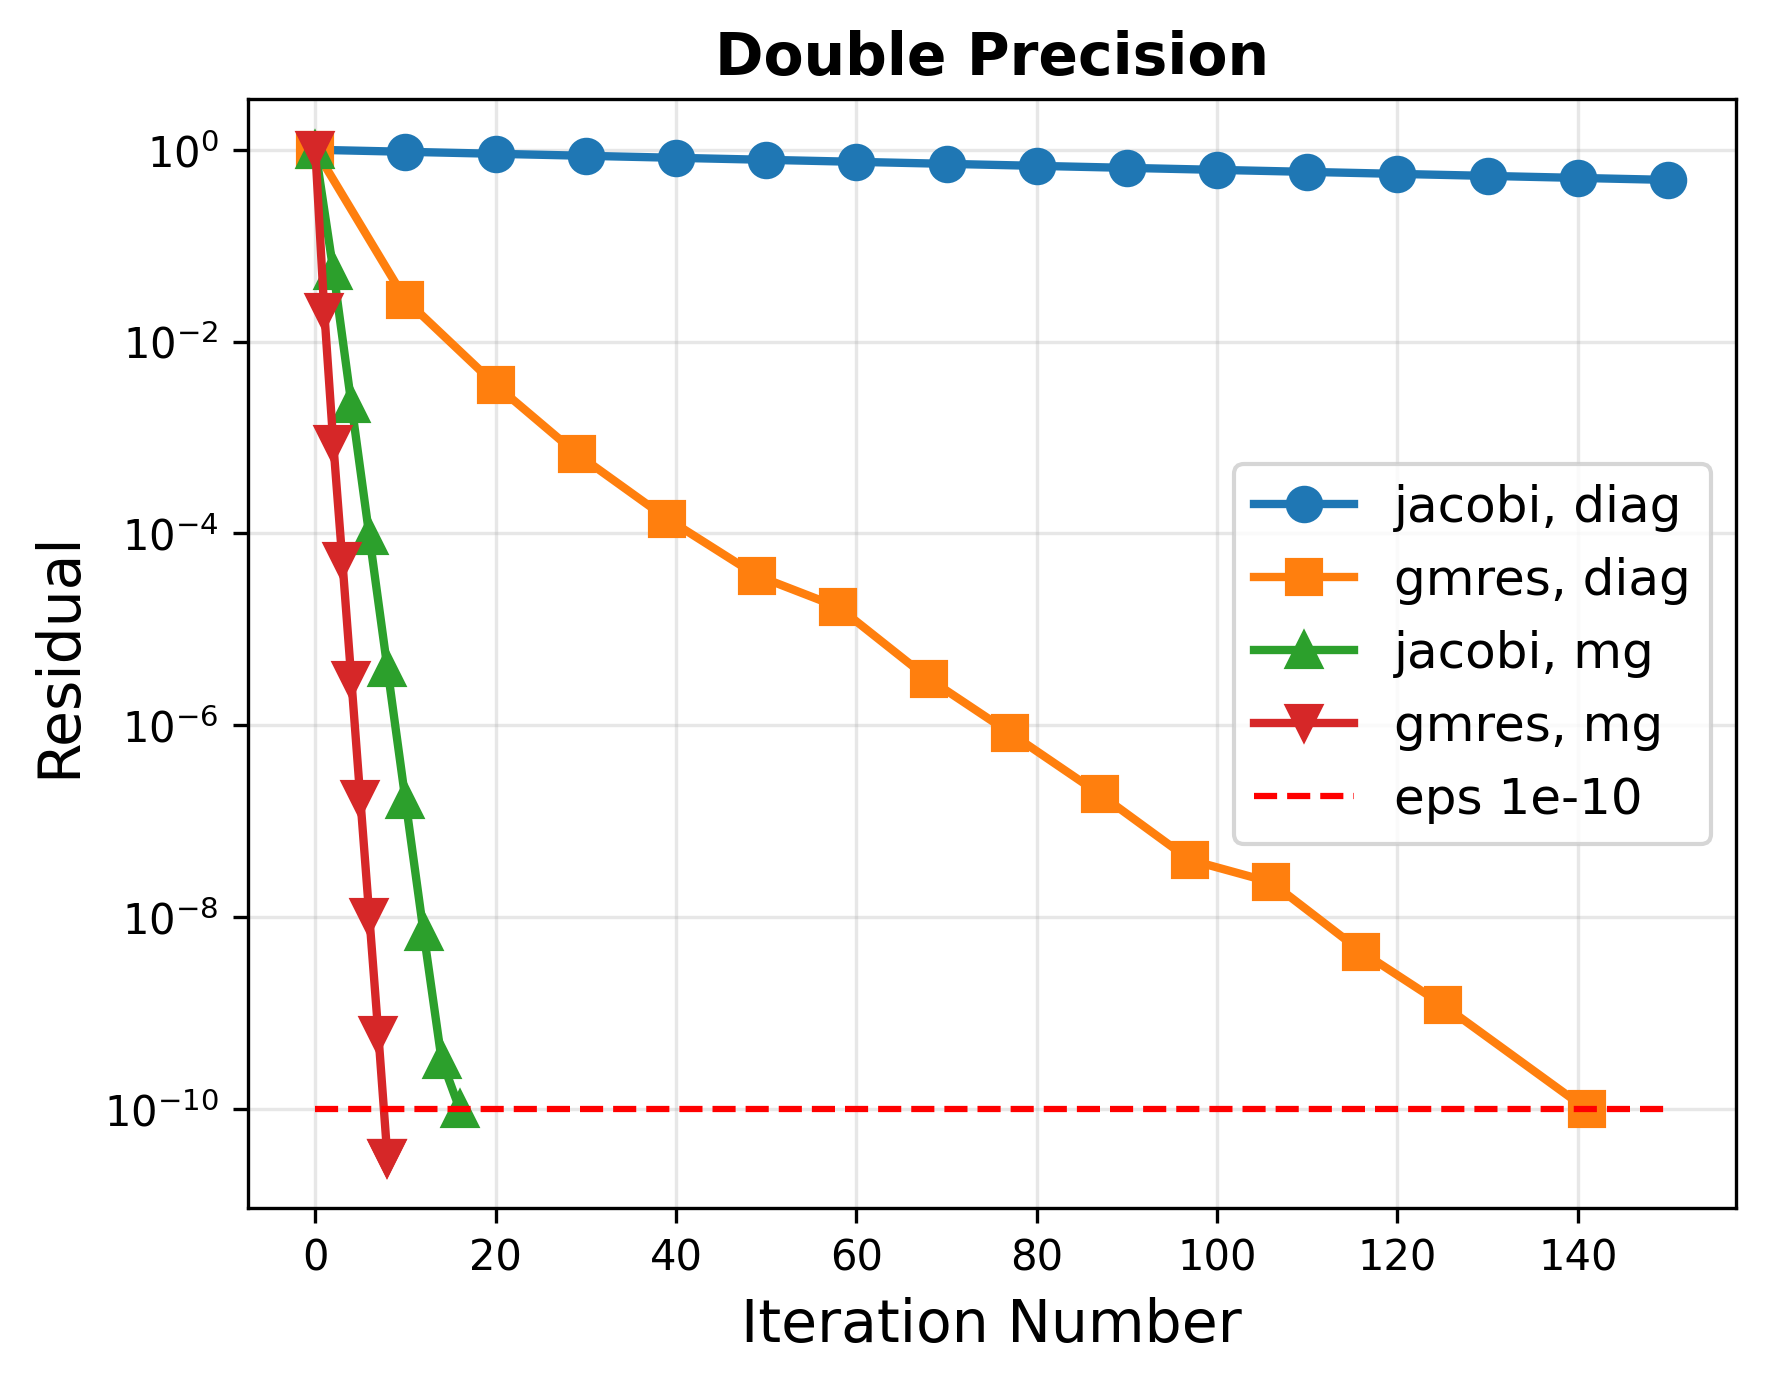

In [21]:
# Define markers and colors for different configurations
markers = ['o', 's', '^', 'v', 'D', 'p', '*', 'h', 'X', 'P']
colors = plt.cm.tab10(np.linspace(0, 1, 10))

# Create plots for each precision type
for precision in ['float', 'double']:
    scale=0.8
    fig, ax = plt.subplots(figsize=(8*scale, 6*scale), dpi=300)

    # Prepare data with iteration counts for sorting
    plot_data = []
    for key, data_dict in convergence_dict.items():
        solver, prec, arch, size = key

        # Check if this precision exists for this configuration
        if precision not in data_dict:
            continue

        iterations, residuals = data_dict[precision]
        num_iterations = iterations[-1]

        plot_data.append((key, iterations, residuals, num_iterations))

    # Sort by number of iterations (descending - most iterations first)
    plot_data.sort(key=lambda x: x[3], reverse=True)

    marker_idx = 0
    for key, iterations, residuals, num_iterations in plot_data:
        solver, prec, arch, size = key

        # Create label
        label = f"{solver}, {prec}"

        # Get marker and color
        marker = markers[marker_idx % len(markers)]
        color = colors[marker_idx % len(colors)]
        marker_idx += 1

        # Plot with markers
        ax.plot(
            iterations, residuals,
            marker=marker,
            color=color,
            label=label,
            markersize=8,
            linewidth=2
        )

    # Add horizontal line for convergence tolerance with label
    tolerance = 1e-10 if precision == 'double' else 1e-5
    tolerance_label = f'eps {tolerance:.0e}'
    ax.hlines(tolerance, 0, 150, linewidth=1.5, linestyles='--', color='red', label=tolerance_label)

    # ax.set_xticks(np.arange(0, 161, 20))
    ax.set_xlabel('Iteration Number', fontsize=14)
    ax.set_ylabel('Residual', fontsize=14)
    ax.set_title(f'{('Single' if precision == 'float' else precision).capitalize()} Precision', fontsize=14, fontweight='bold')
    ax.legend(loc='center right', fontsize=12)
    ax.grid(True, alpha=0.3)

    # Set log scale only on y-axis (base 10)
    ax.set_yscale('log', base=10)

    # Format y-axis ticks (powers of 10)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.tick_params(axis='both', which='minor', labelsize=10)

    # plt.tight_layout()
    plt.show()

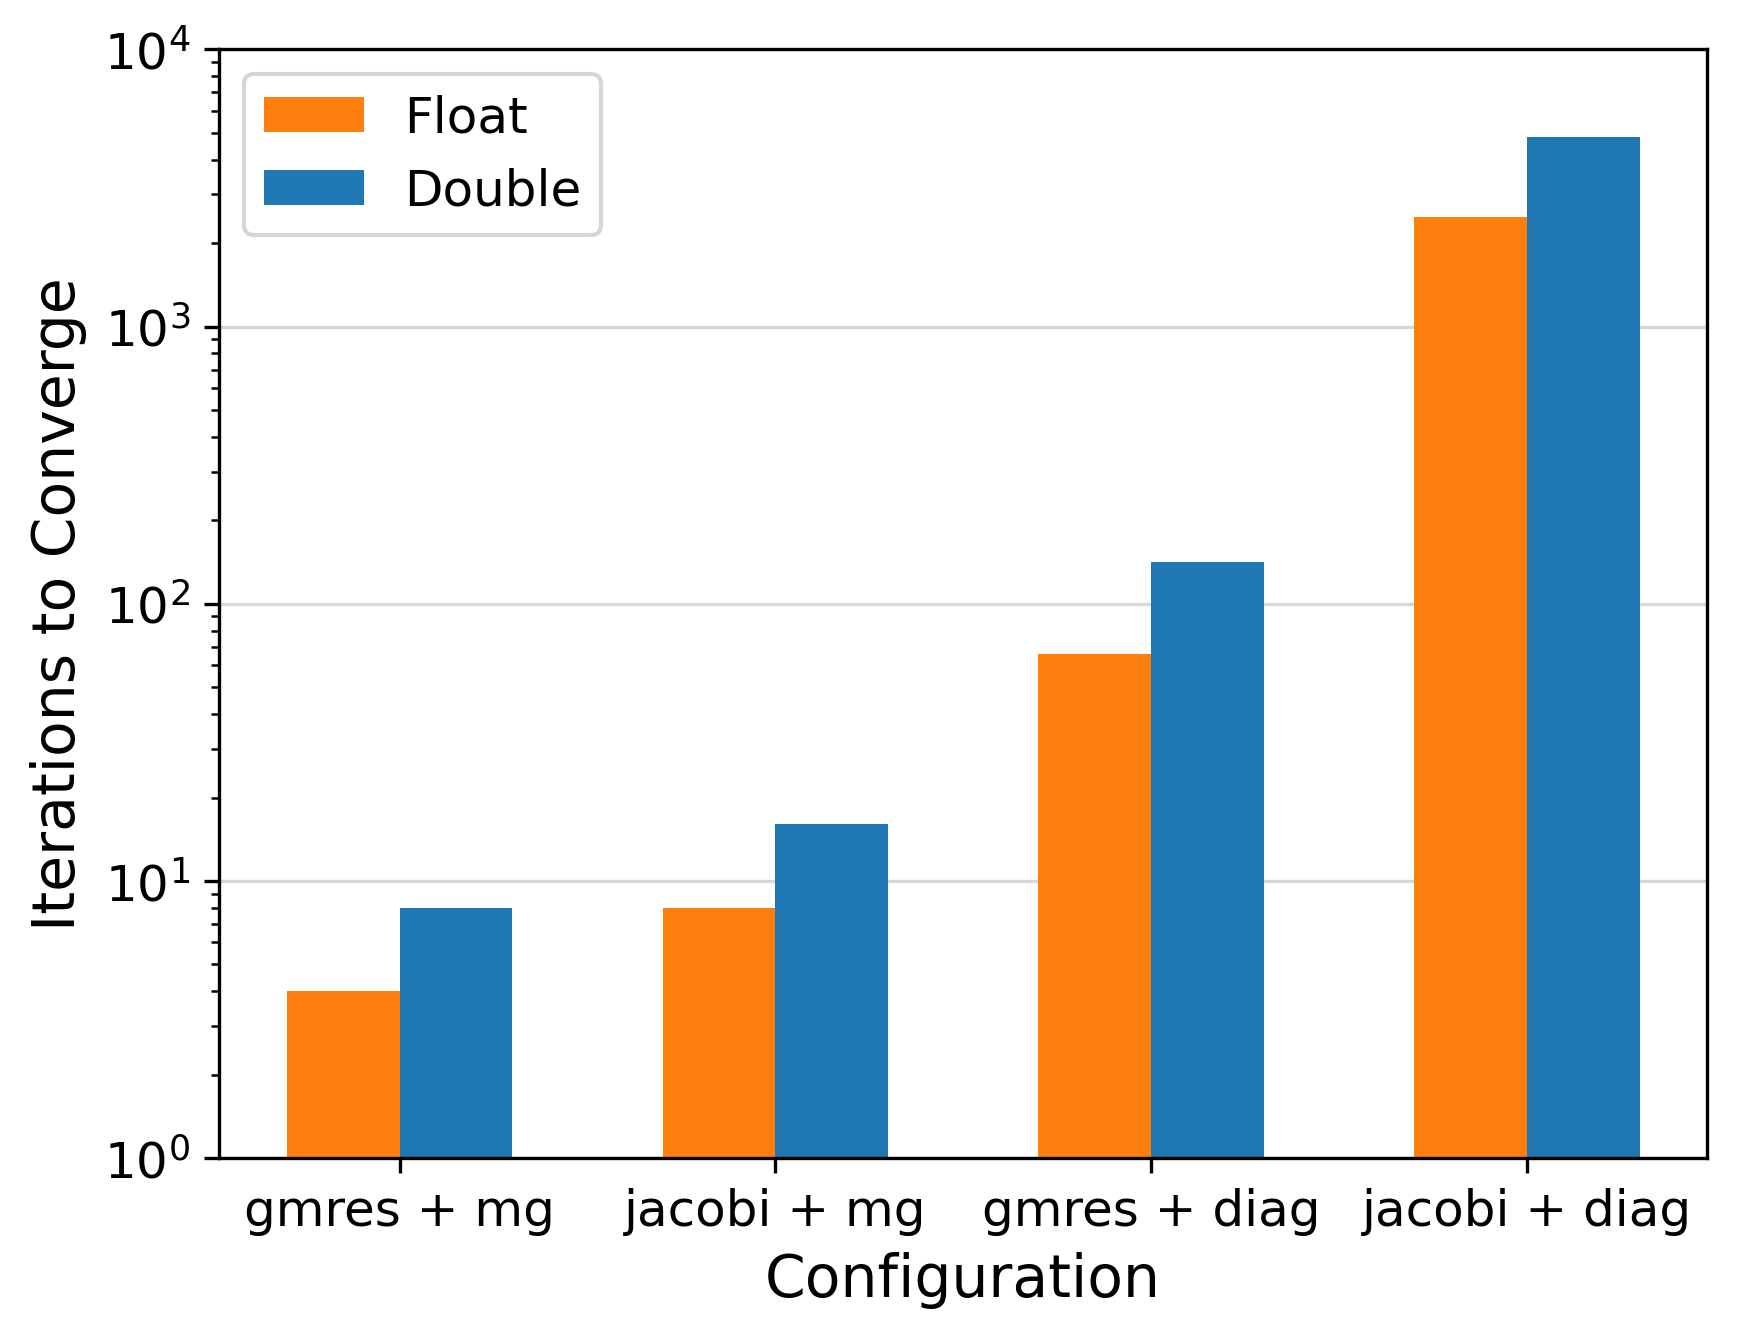

In [20]:
# Bar plot: Number of iterations by configuration
# Configuration parameters
bar_width = 0.3  # Width of each bar
bar_offset = 0.15  # Offset from tick position (positive = right, negative = left)

scale = 0.8
fig, ax = plt.subplots(figsize=(8*scale, 6*scale), dpi=300)
colors = plt.cm.tab10(np.linspace(0, 1, 10))

# Collect iteration counts for each configuration (solver + preconditioner)
config_data = []  # List of (config_name, float_iterations, double_iterations, avg_iterations)

for key, data_dict in convergence_dict.items():
    solver, prec, arch, size = key

    float_iterations = None
    double_iterations = None

    if 'float' in data_dict:
        iterations, residuals = data_dict['float']
        float_iterations = int(iterations[-1])

    if 'double' in data_dict:
        iterations, residuals = data_dict['double']
        double_iterations = int(iterations[-1])

    # Calculate average for sorting (use available values)
    avg_iterations = 0
    count = 0
    if float_iterations is not None:
        avg_iterations += float_iterations
        count += 1
    if double_iterations is not None:
        avg_iterations += double_iterations
        count += 1
    if count > 0:
        avg_iterations = avg_iterations / count
    else:
        continue  # Skip if no data

    # Create configuration label
    config_name = f"{solver} + {prec}"

    config_data.append((config_name, float_iterations, double_iterations, avg_iterations))

# Sort by average iterations (ascending - minimum on left, maximum on right)
config_data.sort(key=lambda x: x[3])

# Extract sorted data
config_names = [item[0] for item in config_data]
float_values = [item[1] for item in config_data]
double_values = [item[2] for item in config_data]

# Create x positions for bars
x_pos = np.arange(len(config_names))

# Calculate bar positions
float_positions = x_pos - bar_offset
double_positions = x_pos + bar_offset

# Plot bars
float_bars = ax.bar(float_positions, float_values, bar_width,
                    label='Float', color=colors[1], zorder=2)
double_bars = ax.bar(double_positions, double_values, bar_width,
                     label='Double', color=colors[0], zorder=2)

# Set labels and title
ax.set_xlabel('Configuration', fontsize=14)
ax.set_ylabel('Iterations to Converge', fontsize=14)
# ax.set_title('Iterations to Convergence by Configuration', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(config_names, fontsize=12)
# ax.set_нticklabels([], fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.5, axis='y', zorder=1)

# Set log scale on y-axis
ax.set_yscale('log', base=10)

# Set specific Y-axis ticks: 10^0, 10^1, 10^2, 10^4
y_ticks = [10**0, 10**1, 10**2, 10**3, 10**4]
ax.set_yticks(y_ticks)
ax.set_yticklabels([f'$10^{{{int(np.log10(t))}}}$' for t in y_ticks], fontsize=12)

# Format ticks
ax.tick_params(axis='both', which='major', labelsize=12)
ax.tick_params(axis='both', which='minor', labelsize=12)

# plt.tight_layout()
plt.show()

---

# Grid Size Experiment Visualization

This section visualizes how the number of iterations required for convergence depends on grid size.

In [62]:
# Set the base path for grid size experiments
# This should point to the folder containing grid size subdirectories (data/2/, data/4/, etc.)
GRID_SIZE_BASE_PATH = "data/conv_biharmonic_grid_prod"

# Find all grid size directories
base_path = Path(GRID_SIZE_BASE_PATH)
grid_size_dirs = [d for d in base_path.iterdir() if d.is_dir() and d.name.isdigit()]

print(f"Found {len(grid_size_dirs)} grid size directories:")
for d in sorted(grid_size_dirs, key=lambda x: int(x.name)):
    print(f"  - {d.name}")

Found 8 grid size directories:
  - 2
  - 4
  - 8
  - 16
  - 32
  - 64
  - 128
  - 256


In [63]:
# Parse folder name to extract parameters
def parse_folder_name(folder_name):
    """Parse folder name like 'jacobi_diag_cuda_float_32_20260127_181708' into parameters"""
    parts = folder_name.split('_')
    if len(parts) >= 5:
        solver = parts[0].lower()
        prec = parts[1].lower()
        arch = parts[2].lower()
        dtype = parts[3].lower()  # 'float' or 'double'
        size = int(parts[4])
        return solver, prec, arch, size, dtype
    return None

# Function to check if calculation converged by reading log file
def check_convergence(log_file_path):
    """Check if calculation converged by reading log file"""
    try:
        with open(log_file_path, 'r') as f:
            content = f.read()
            # Look for "Converged: yes" or "Converged: no"
            if "Converged:                  yes" in content:
                return True
            elif "Converged:                  no" in content:
                return False
            # Also check for ERROR messages
            if "ERROR:" in content and "failed to converge" in content:
                return False
    except Exception as e:
        print(f"Warning: Could not read log file {log_file_path}: {e}")
        return False
    return None  # Unknown status

# Store data: key = (solver, prec, arch), value = {dtype: {grid_size: iterations}}
grid_size_dict = {}

for grid_size_dir in sorted(grid_size_dirs, key=lambda x: int(x.name)):
    grid_size = int(grid_size_dir.name)

    # Look for conv_biharmonic_prod subdirectory
    conv_prod_dir = grid_size_dir
    if not conv_prod_dir.exists():
        print(f"Warning: {conv_prod_dir} does not exist, skipping grid size {grid_size}")
        continue

    # Find all conv_history.dat files in this grid size
    conv_files = list(conv_prod_dir.glob("*/conv_history.dat"))

    for conv_file in sorted(conv_files):
        folder_name = conv_file.parent.name
        params = parse_folder_name(folder_name)

        if params is None:
            print(f"Warning: Could not parse folder name: {folder_name}")
            continue

        solver, prec, arch, size_from_name, dtype = params

        # Verify grid size matches
        if size_from_name != grid_size:
            print(f"Warning: Grid size mismatch in {folder_name}: expected {grid_size}, got {size_from_name}")
            continue

        # Check convergence status
        log_file = conv_file.parent / "log.txt"
        converged = check_convergence(log_file)

        if converged is False:
            print(f"SKIPPING (not converged): {solver} + {prec} ({dtype}, N={grid_size})")
            continue
        elif converged is None:
            print(f"WARNING (unknown status): {solver} + {prec} ({dtype}, N={grid_size})")
            # Continue anyway, but warn

        # Read convergence history
        try:
            data = np.loadtxt(conv_file)
            if data.ndim == 1:
                iterations = np.array([data[0]])
            else:
                iterations = data[:, 0]

            # Get final iteration number
            final_iteration = int(iterations[-1])

            # Store in dictionary
            key = (solver, prec, arch)
            if key not in grid_size_dict:
                grid_size_dict[key] = {}
            if dtype not in grid_size_dict[key]:
                grid_size_dict[key][dtype] = {}

            grid_size_dict[key][dtype][grid_size] = final_iteration
            print(f"Loaded: {solver} + {prec} ({dtype}, N={grid_size}) - {final_iteration} iterations")

        except Exception as e:
            print(f"Error reading {conv_file}: {e}")

print(f"\nTotal configurations: {len(grid_size_dict)}")

Loaded: gmres + diag (double, N=2) - 2 iterations
Loaded: gmres + diag (float, N=2) - 2 iterations
Loaded: gmres + mg (double, N=2) - 2 iterations
Loaded: gmres + mg (float, N=2) - 1 iterations
Loaded: jacobi + diag (double, N=2) - 22 iterations
Loaded: jacobi + diag (float, N=2) - 7 iterations
Loaded: jacobi + mg (double, N=2) - 3 iterations
Loaded: jacobi + mg (float, N=2) - 1 iterations
Loaded: gmres + diag (double, N=4) - 8 iterations
Loaded: gmres + diag (float, N=4) - 5 iterations
Loaded: gmres + mg (double, N=4) - 4 iterations
Loaded: gmres + mg (float, N=4) - 2 iterations
Loaded: jacobi + diag (double, N=4) - 74 iterations
Loaded: jacobi + diag (float, N=4) - 24 iterations
Loaded: jacobi + mg (double, N=4) - 8 iterations
Loaded: jacobi + mg (float, N=4) - 3 iterations
Loaded: gmres + diag (double, N=8) - 23 iterations
Loaded: gmres + diag (float, N=8) - 10 iterations
Loaded: gmres + mg (double, N=8) - 6 iterations
Loaded: gmres + mg (float, N=8) - 2 iterations
Loaded: jacobi + 

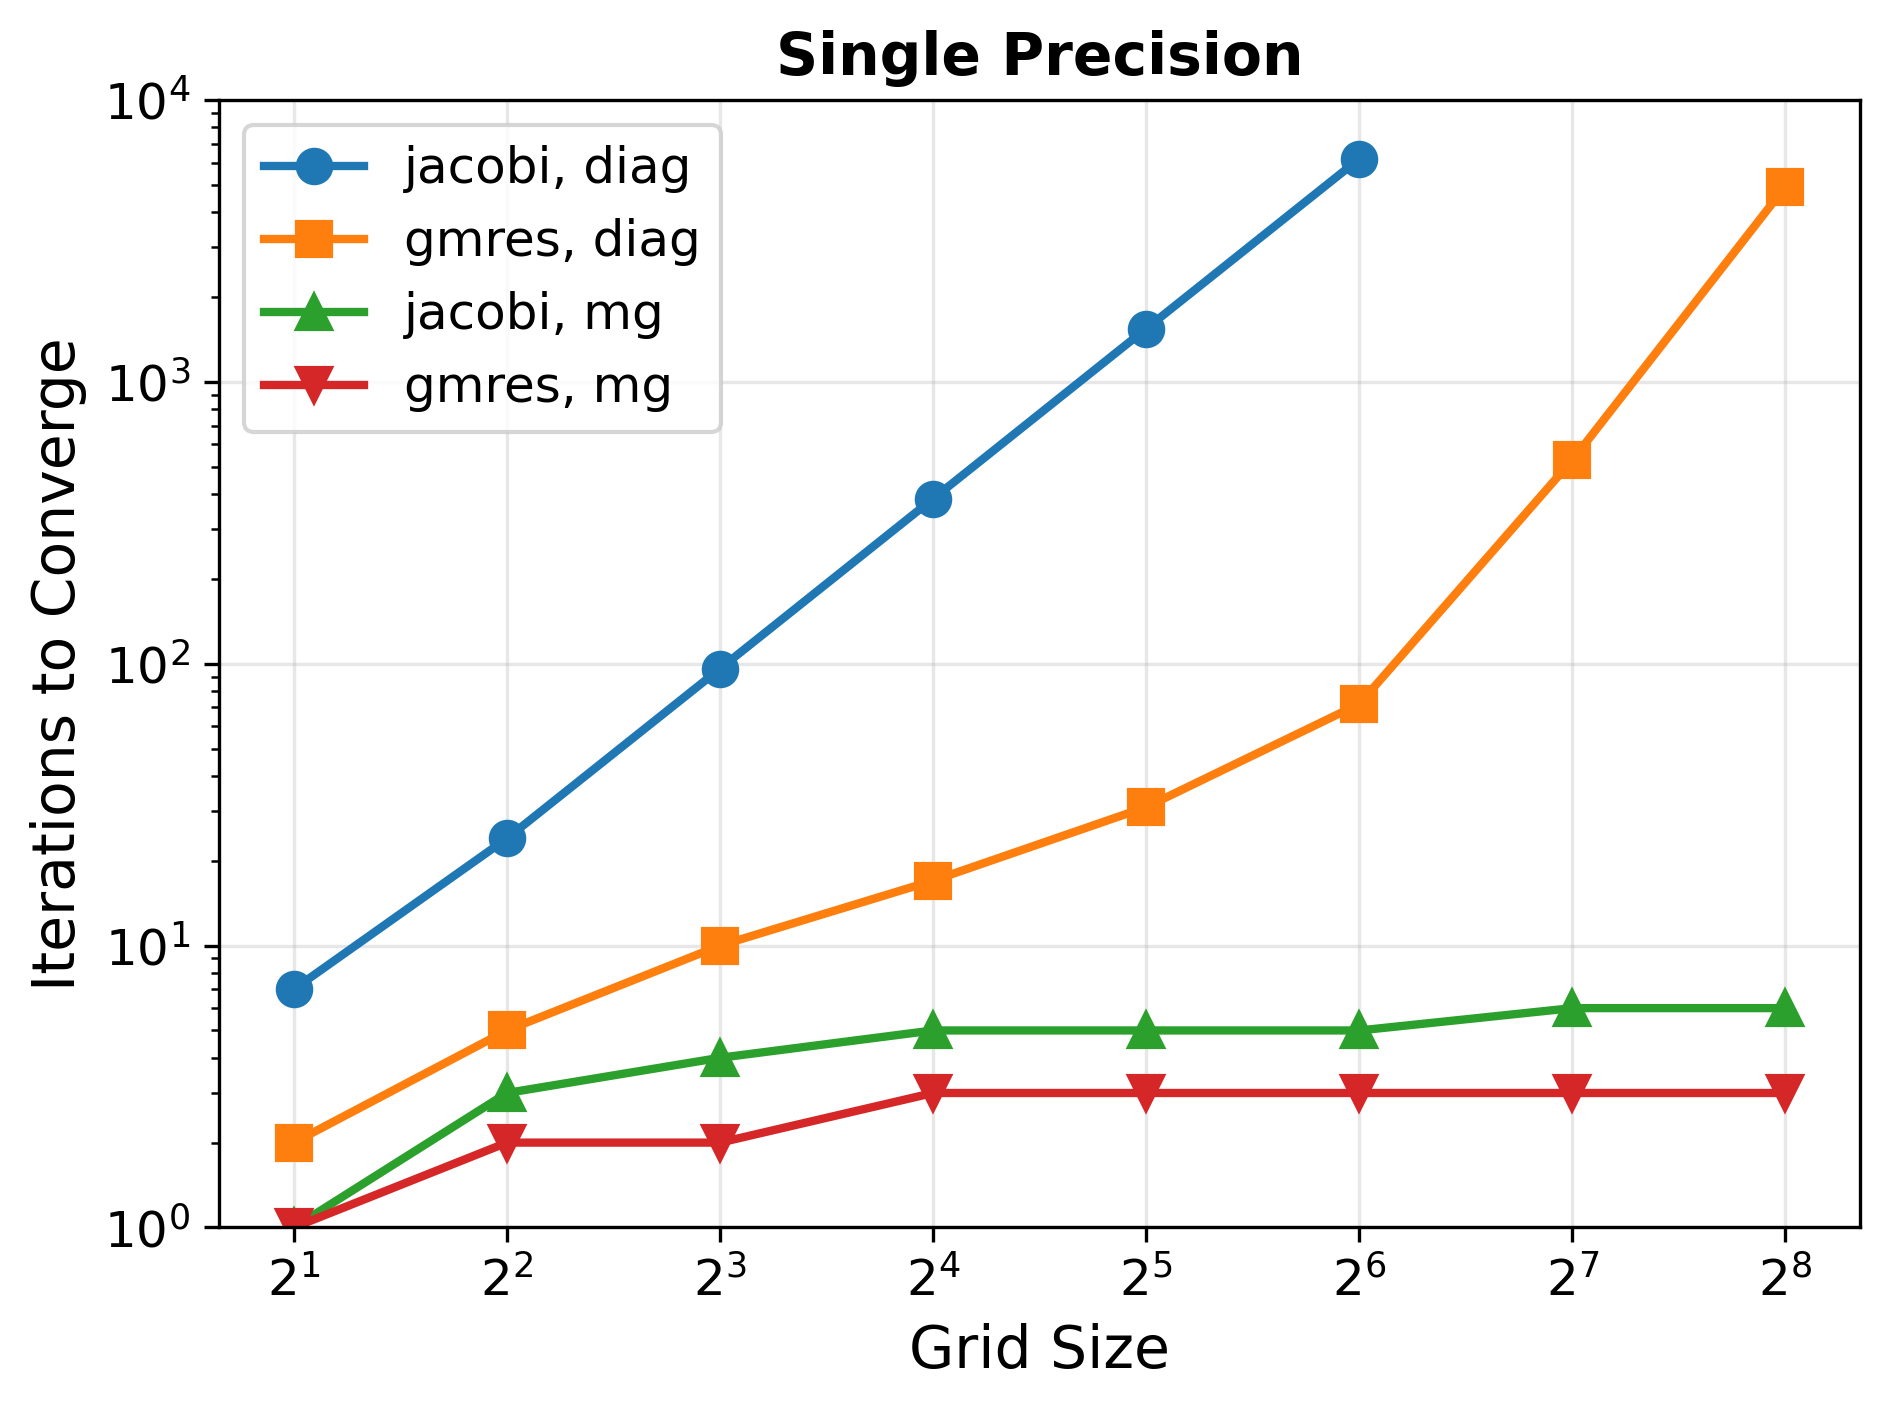

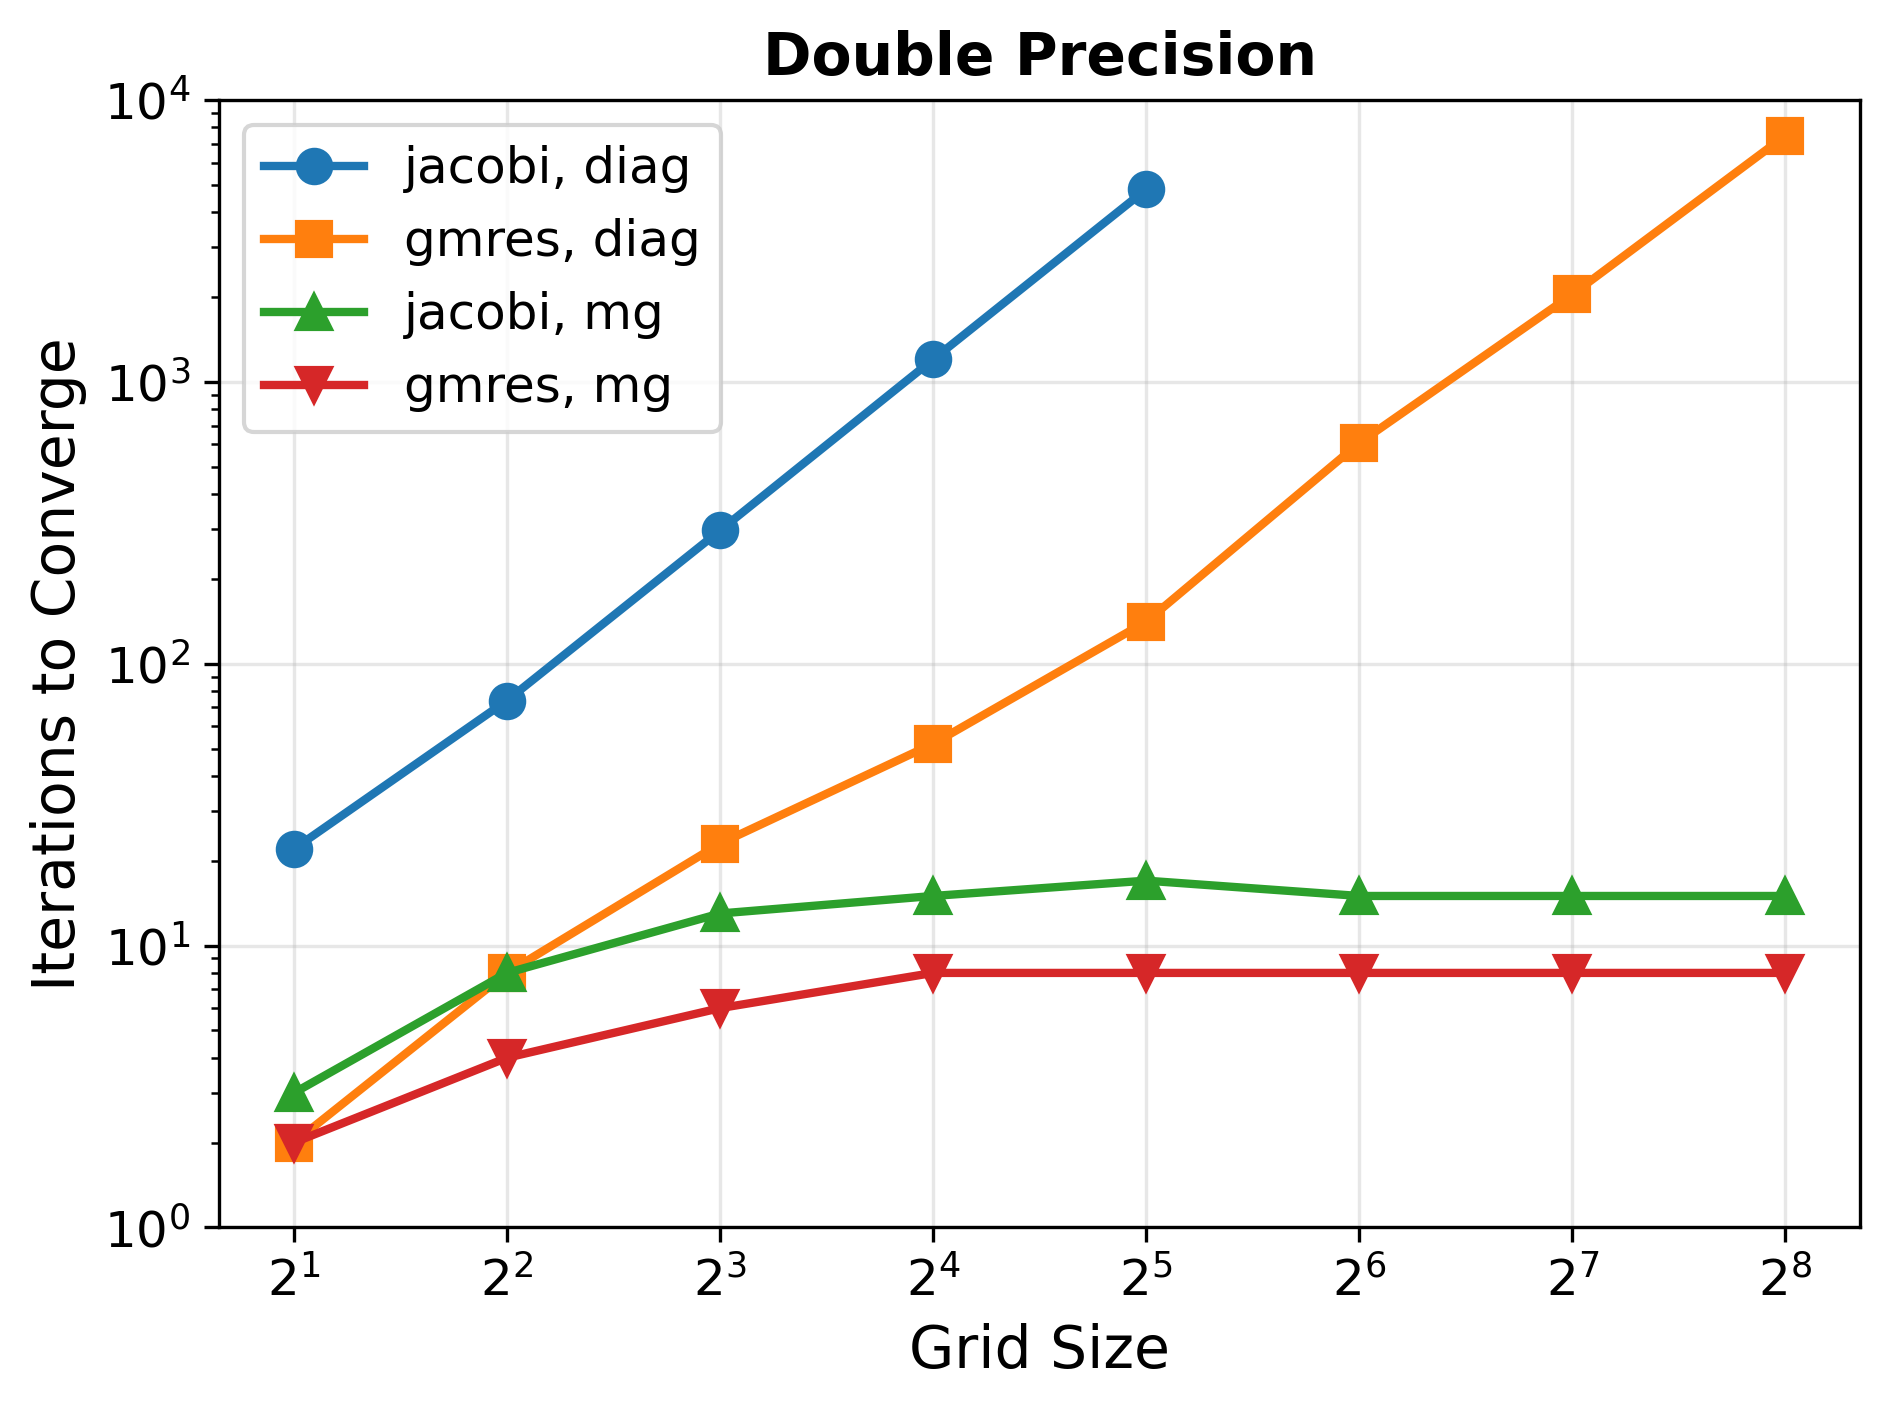

In [67]:
# Define markers and colors for different configurations
markers = ['o', 's', '^', 'v', 'D', 'p', '*', 'h', 'X', 'P']
colors = plt.cm.tab10(np.linspace(0, 1, 10))

# Maximum value to display (1e4)
MAX_ITERATIONS = 1e4

# Create plots for each precision type
for precision in ['float', 'double']:
    scale = 0.8
    fig, ax = plt.subplots(figsize=(8*scale, 6*scale), dpi=300)

    # Prepare data for plotting
    plot_data = []
    for key, dtype_dict in grid_size_dict.items():
        solver, prec, arch = key

        # Check if this precision exists
        if precision not in dtype_dict:
            continue

        grid_sizes = sorted(dtype_dict[precision].keys())
        iterations = [dtype_dict[precision][size] for size in grid_sizes]

        # Filter out points with iterations > MAX_ITERATIONS
        filtered_grid_sizes = []
        filtered_iterations = []
        for gs, it in zip(grid_sizes, iterations):
            if it <= MAX_ITERATIONS:
                filtered_grid_sizes.append(gs)
                filtered_iterations.append(it)

        # Skip if no valid points
        if len(filtered_iterations) == 0:
            continue

        # Calculate maximum iterations for sorting
        max_iterations = max(filtered_iterations) if filtered_iterations else 0

        # Create label
        label = f"{solver}, {prec}"

        plot_data.append((key, filtered_grid_sizes, filtered_iterations, max_iterations, label))

    # Sort by maximum iterations (descending - most iterations first in legend)
    plot_data.sort(key=lambda x: x[2][2], reverse=True)

    marker_idx = 0
    for key, grid_sizes, iterations, max_iterations, label in plot_data:
        # Get marker and color
        marker = markers[marker_idx % len(markers)]
        color = colors[marker_idx % len(colors)]
        marker_idx += 1

        # Plot with markers
        ax.plot(
            grid_sizes, iterations,
            marker=marker,
            color=color,
            label=label,
            markersize=8,
            linewidth=2
        )

    ax.set_xlabel('Grid Size', fontsize=14)
    ax.set_ylabel('Iterations to Converge', fontsize=14)
    # ax.set_title(f'Iterations vs Grid Size - {precision.capitalize()} Precision', fontsize=14, fontweight='bold')
    ax.set_title(f'{('Single' if precision == 'float' else precision).capitalize()} Precision', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=12)
    ax.grid(True, alpha=0.3)

    # Set y-axis limit to MAX_ITERATIONS
    ax.set_ylim(10**0, MAX_ITERATIONS)

    # Update y_ticks to only go up to 1e4
    y_ticks = [10**0, 10**1, 10**2, 10**3, 10**4]
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f'$10^{{{int(np.log10(t))}}}$' for t in y_ticks], fontsize=12)

    # Set log scale on x-axis (base 2)
    ax.set_xscale('log', base=2)
    ax.set_yscale('log', base=10)

    # Format ticks
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.tick_params(axis='both', which='minor', labelsize=12)

    plt.tight_layout()
    plt.show()

---

# Cahn-Hilliard Grid Size Experiments

In [16]:
# Set the base path for Cahn-Hilliard grid size experiments
CAHN_HILLIARD_GRID_BASE_PATH = "data/conv_cahn_hilliard_grid_prod"

# Find all grid size directories
cahn_hilliard_base_path = Path(CAHN_HILLIARD_GRID_BASE_PATH)
cahn_hilliard_grid_size_dirs = [d for d in cahn_hilliard_base_path.iterdir() if d.is_dir() and d.name.isdigit()]

print(f"Found {len(cahn_hilliard_grid_size_dirs)} grid size directories for Cahn-Hilliard:")
for d in sorted(cahn_hilliard_grid_size_dirs, key=lambda x: int(x.name)):
    print(f"  - {d.name}")

Found 7 grid size directories for Cahn-Hilliard:
  - 4
  - 8
  - 16
  - 32
  - 64
  - 128
  - 256


In [17]:
# Parse folder name to extract parameters for Cahn-Hilliard
def parse_cahn_hilliard_folder_name(folder_name):
    """Parse folder name like 'gmres_mg_cuda_float_32_20260131_131828' into parameters"""
    parts = folder_name.split('_')
    if len(parts) >= 5:
        solver = parts[0].lower()
        prec = parts[1].lower()
        arch = parts[2].lower()
        dtype = parts[3].lower()  # 'float' or 'double'
        size = int(parts[4])
        return solver, prec, arch, size, dtype
    return None

# Store data for Cahn-Hilliard: {solver_prec: {grid_size: {dtype: {total_linear_iters, newton_iters}}}}
cahn_hilliard_data = {}

for grid_size_dir in sorted(cahn_hilliard_grid_size_dirs, key=lambda x: int(x.name)):
    grid_size = int(grid_size_dir.name)

    # Find all result directories in this grid size
    result_dirs = [d for d in grid_size_dir.iterdir() if d.is_dir()]

    for result_dir in sorted(result_dirs):
        folder_name = result_dir.name
        params = parse_cahn_hilliard_folder_name(folder_name)

        if params is None:
            print(f"Warning: Could not parse folder name: {folder_name}")
            continue

        solver, prec, arch, size_from_name, dtype = params

        # Verify grid size matches
        if size_from_name != grid_size:
            print(f"Warning: Grid size mismatch in {folder_name}: expected {grid_size}, got {size_from_name}")
            continue

        # Create solver+prec key
        solver_prec_key = f"{solver}_{prec}"

        # Check convergence status
        log_file = result_dir / "log.txt"
        if not log_file.exists():
            print(f"Warning: Log file not found for {folder_name}")
            continue

        try:
            with open(log_file, 'r') as f:
                content = f.read()
                if "Converged:                  no" in content:
                    print(f"SKIPPING (not converged): {solver} + {prec} ({dtype}, N={grid_size})")
                    continue
        except Exception as e:
            print(f"Warning: Could not read log file {log_file}: {e}")
            continue

        # Read times.dat to get total linear solver iterations
        times_file = result_dir / "times.dat"
        total_linear_iters = 0
        newton_iters = 0

        if times_file.exists():
            try:
                # Read times.dat (skip header, sum iters_n column)
                with open(times_file, 'r') as f:
                    lines = f.readlines()
                    for line in lines[1:]:  # Skip header
                        if line.strip():
                            parts = line.strip().split(',')
                            if len(parts) >= 7:
                                iters_n = int(float(parts[6]))  # iters_n is column 6 (0-indexed)
                                total_linear_iters += iters_n
                                newton_iters += 1  # Count Newton iterations
            except Exception as e:
                print(f"Error reading times.dat for {folder_name}: {e}")
                continue

        # Also get Newton iterations from nonlinear_history.dat (more reliable)
        nonlinear_file = result_dir / "nonlinear_history.dat"
        if nonlinear_file.exists():
            try:
                with open(nonlinear_file, 'r') as f:
                    lines = f.readlines()
                    # Skip header, get last iteration number
                    newton_iters = 0
                    for line in lines[1:]:  # Skip header
                        if line.strip():
                            parts = line.strip().split()
                            if len(parts) >= 1:
                                newton_iters = int(parts[0])
            except Exception as e:
                print(f"Error reading nonlinear_history.dat for {folder_name}: {e}")

        # Store data
        if solver_prec_key not in cahn_hilliard_data:
            cahn_hilliard_data[solver_prec_key] = {}

        if grid_size not in cahn_hilliard_data[solver_prec_key]:
            cahn_hilliard_data[solver_prec_key][grid_size] = {}

        cahn_hilliard_data[solver_prec_key][grid_size][dtype] = {
            'total_linear_iters': total_linear_iters,
            'newton_iters': newton_iters
        }

        print(f"Loaded: {solver} + {prec} ({dtype}, N={grid_size}) - Newton: {newton_iters}, Total Linear: {total_linear_iters}")

print(f"\nTotal solver+prec combinations: {len(cahn_hilliard_data)}")
for key in sorted(cahn_hilliard_data.keys()):
    print(f"  - {key}: {len(cahn_hilliard_data[key])} grid sizes")

Loaded: gmres + mg (double, N=4) - Newton: 3, Total Linear: 5
Loaded: gmres + mg (float, N=4) - Newton: 2, Total Linear: 4
Loaded: jacobi + diag (double, N=4) - Newton: 4, Total Linear: 72
Loaded: jacobi + diag (float, N=4) - Newton: 2, Total Linear: 36
Loaded: gmres + mg (double, N=8) - Newton: 3, Total Linear: 7
Loaded: gmres + mg (float, N=8) - Newton: 2, Total Linear: 5
Loaded: jacobi + diag (double, N=8) - Newton: 4, Total Linear: 218
Loaded: jacobi + diag (float, N=8) - Newton: 2, Total Linear: 76
Loaded: gmres + mg (double, N=16) - Newton: 3, Total Linear: 9
Loaded: gmres + mg (float, N=16) - Newton: 1, Total Linear: 3
Loaded: jacobi + diag (double, N=16) - Newton: 4, Total Linear: 645
Loaded: jacobi + diag (float, N=16) - Newton: 2, Total Linear: 155
Loaded: gmres + mg (double, N=32) - Newton: 4, Total Linear: 15
Loaded: gmres + mg (float, N=32) - Newton: 2, Total Linear: 7
Loaded: jacobi + diag (double, N=32) - Newton: 4, Total Linear: 1682
Loaded: jacobi + diag (float, N=32) 

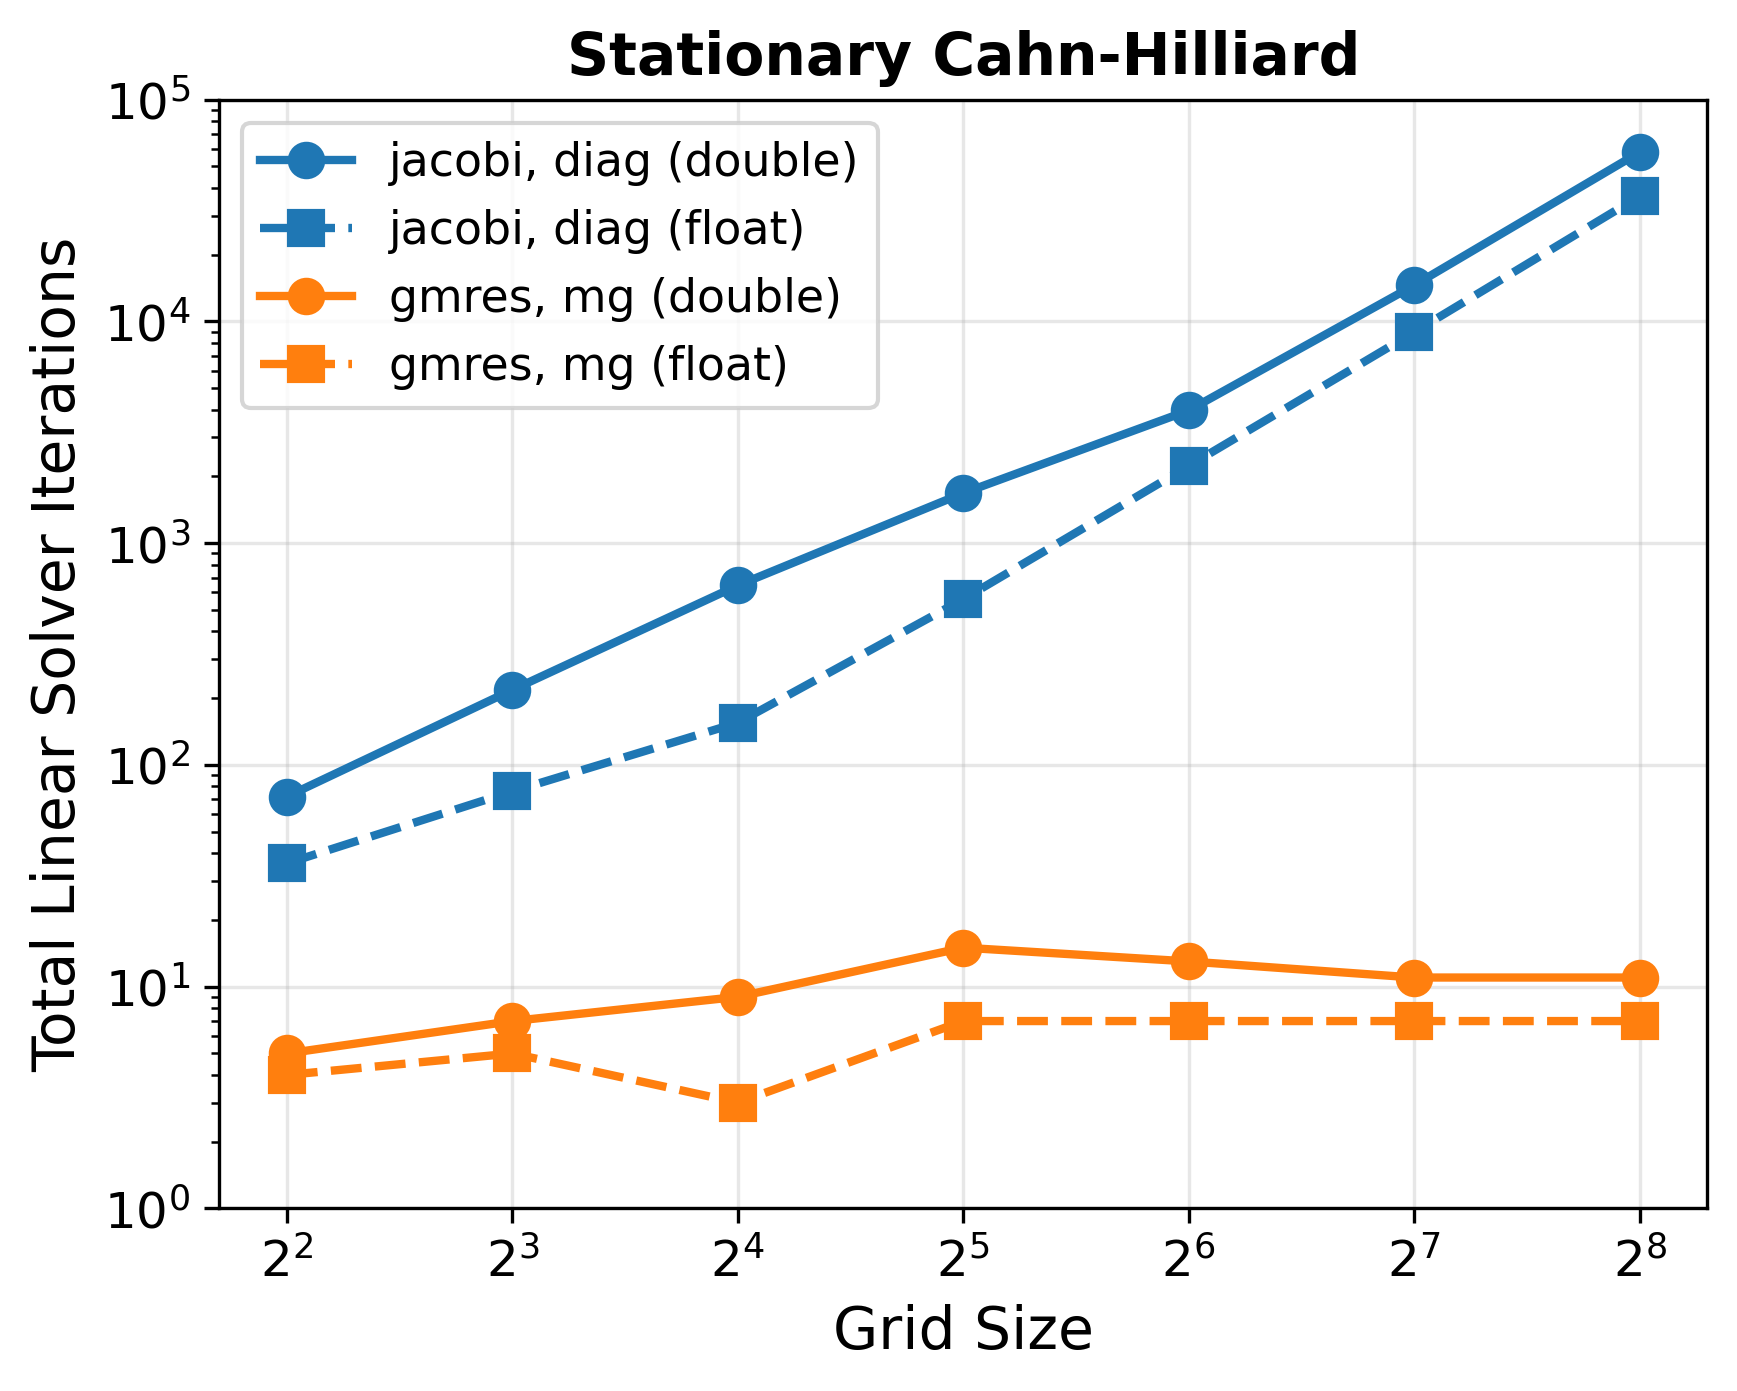

In [18]:
# Plot 1: Total linear solver iterations vs grid size
scale = 0.8
fig, ax = plt.subplots(figsize=(8*scale, 6*scale), dpi=300)

# Prepare data for plotting: {solver_prec: {dtype: {grid_sizes, linear_iters}}}
plot_data = {}

for solver_prec_key in sorted(cahn_hilliard_data.keys()):
    plot_data[solver_prec_key] = {
        'float': {'grid_sizes': [], 'linear_iters': []},
        'double': {'grid_sizes': [], 'linear_iters': []}
    }

    for grid_size in sorted(cahn_hilliard_data[solver_prec_key].keys()):
        if 'float' in cahn_hilliard_data[solver_prec_key][grid_size]:
            plot_data[solver_prec_key]['float']['grid_sizes'].append(grid_size)
            plot_data[solver_prec_key]['float']['linear_iters'].append(
                cahn_hilliard_data[solver_prec_key][grid_size]['float']['total_linear_iters'])

        if 'double' in cahn_hilliard_data[solver_prec_key][grid_size]:
            plot_data[solver_prec_key]['double']['grid_sizes'].append(grid_size)
            plot_data[solver_prec_key]['double']['linear_iters'].append(
                cahn_hilliard_data[solver_prec_key][grid_size]['double']['total_linear_iters'])

# Plot lines for each solver+prec combination
colors = {'jacobi_diag': '#1f77b4', 'gmres_mg': '#ff7f0e'}
markers = {'float': 's', 'double': 'o'}
linestyles = {'float': '--', 'double': '-'}

# Order: jacobi_diag first, then gmres_mg
solver_prec_order = ['jacobi_diag', 'gmres_mg']
for solver_prec_key in solver_prec_order:
    if solver_prec_key not in plot_data:
        continue
    solver_prec_label = solver_prec_key.replace('_', ', ')
    color = colors.get(solver_prec_key, '#2ca02c')

    # Plot double first, then float
    if plot_data[solver_prec_key]['double']['grid_sizes']:
        ax.plot(plot_data[solver_prec_key]['double']['grid_sizes'],
                plot_data[solver_prec_key]['double']['linear_iters'],
                marker=markers['double'], linestyle=linestyles['double'],
                label=f'{solver_prec_label} (double)', linewidth=2, markersize=8, color=color)

    # Plot float
    if plot_data[solver_prec_key]['float']['grid_sizes']:
        ax.plot(plot_data[solver_prec_key]['float']['grid_sizes'],
                plot_data[solver_prec_key]['float']['linear_iters'],
                marker=markers['float'], linestyle=linestyles['float'],
                label=f'{solver_prec_label} (float)', linewidth=2, markersize=8, color=color)

ax.set_xlabel('Grid Size', fontsize=14)
ax.set_ylabel('Total Linear Solver Iterations', fontsize=14)
ax.set_title('Stationary Cahn-Hilliard', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

# Set log scale on x-axis (base 2)
ax.set_xscale('log', base=2)
ax.set_yscale('log', base=10)

y_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5]
ax.set_yticks(y_ticks)
ax.set_yticklabels([f'$10^{{{int(np.log10(t))}}}$' for t in y_ticks], fontsize=12)

# Format ticks
ax.tick_params(axis='both', which='major', labelsize=12)
ax.tick_params(axis='both', which='minor', labelsize=12)

# plt.tight_layout()
plt.show()

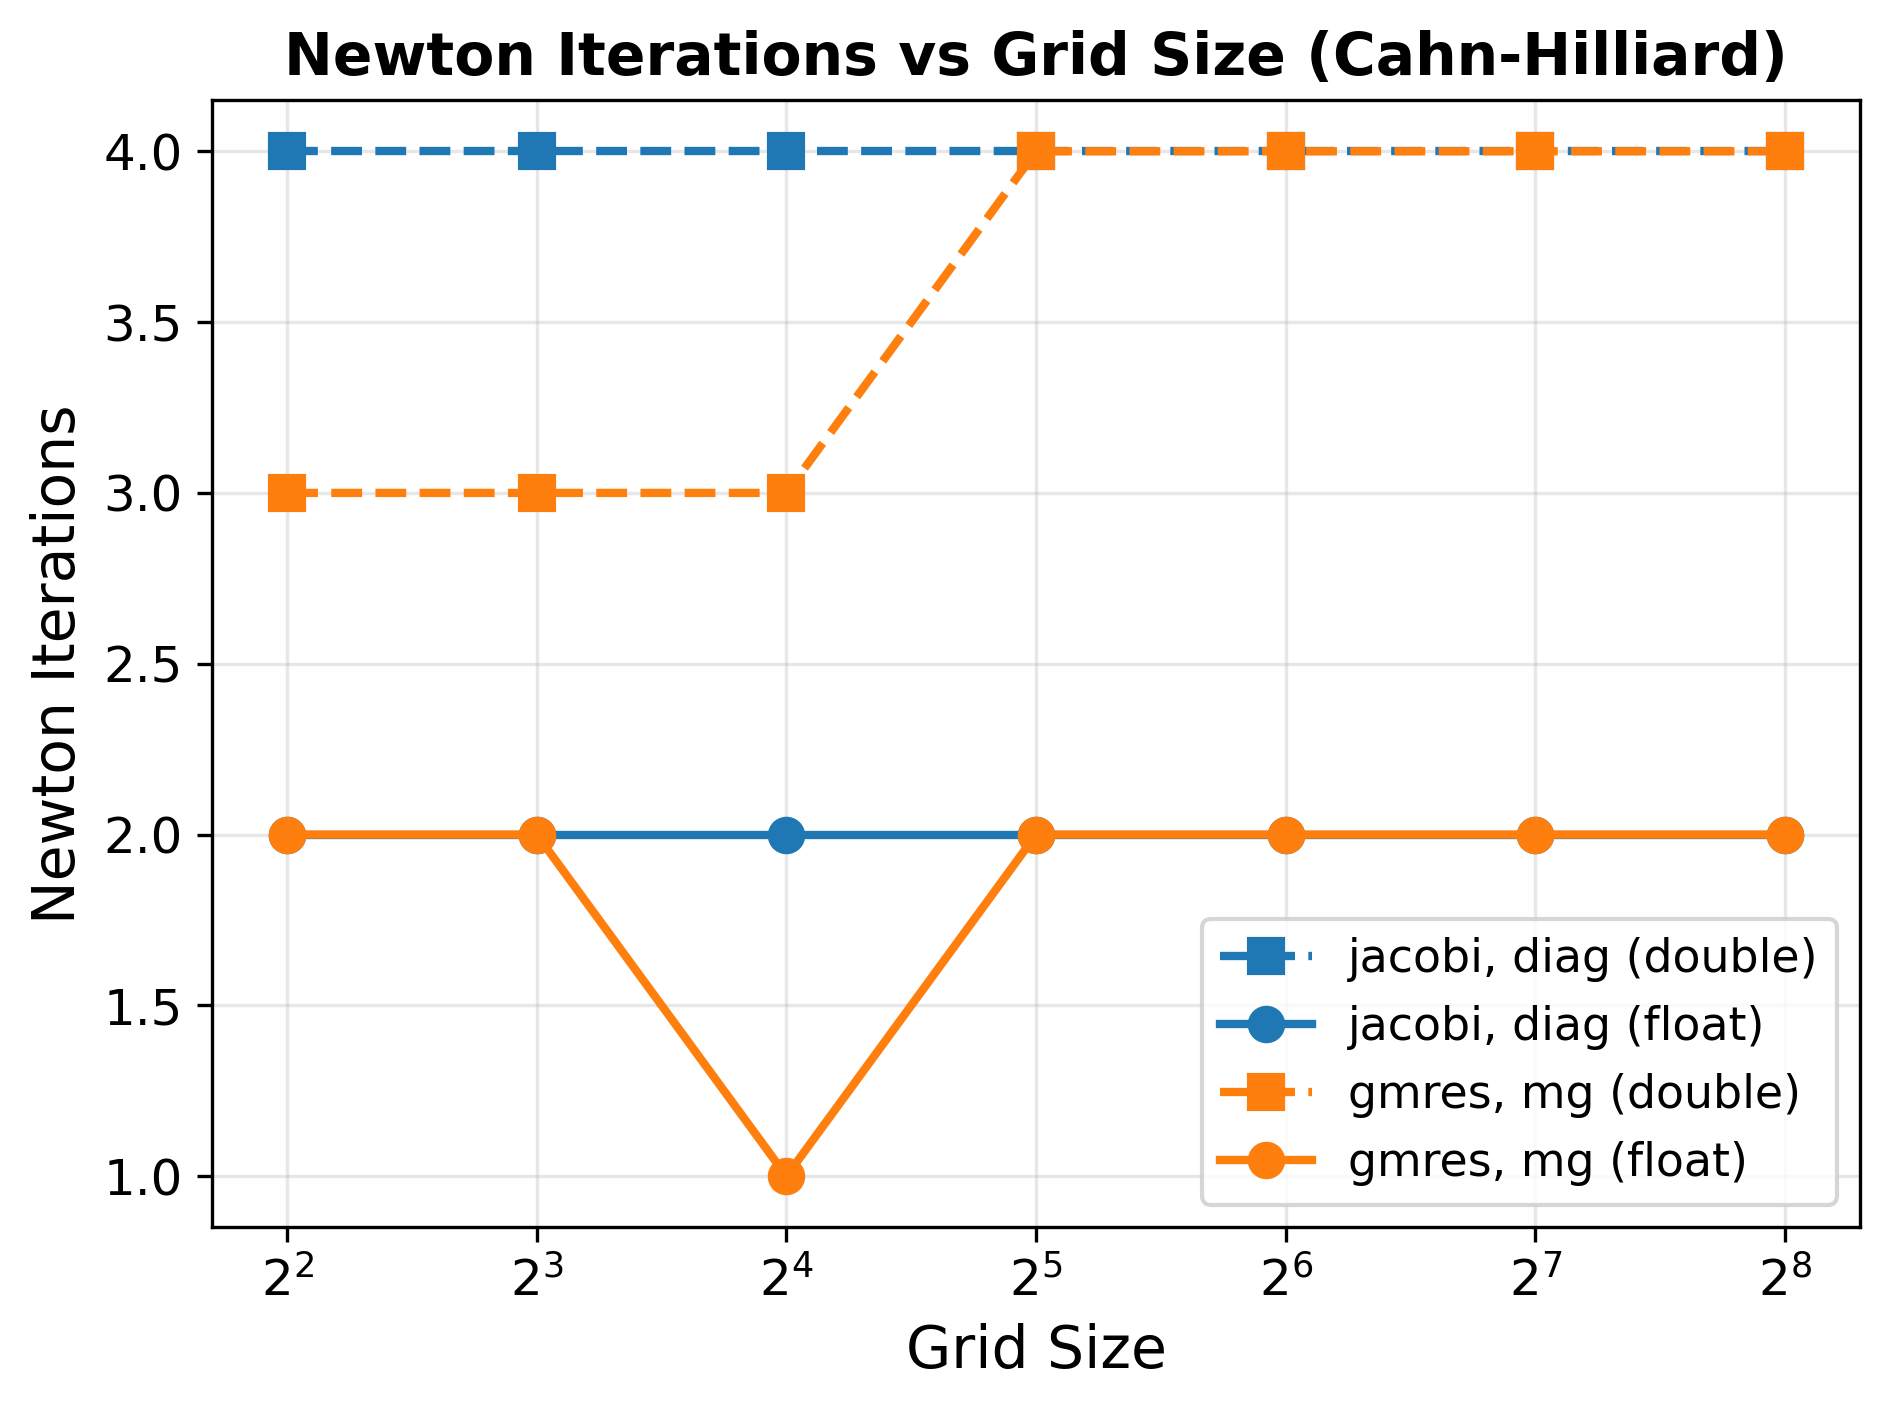

In [19]:
# Plot 2: Newton iterations vs grid size
scale = 0.8
fig, ax = plt.subplots(figsize=(8*scale, 6*scale), dpi=300)

# Prepare data for plotting
plot_data = {}

for solver_prec_key in sorted(cahn_hilliard_data.keys()):
    plot_data[solver_prec_key] = {
        'float': {'grid_sizes': [], 'newton_iters': []},
        'double': {'grid_sizes': [], 'newton_iters': []}
    }

    for grid_size in sorted(cahn_hilliard_data[solver_prec_key].keys()):
        if 'float' in cahn_hilliard_data[solver_prec_key][grid_size]:
            plot_data[solver_prec_key]['float']['grid_sizes'].append(grid_size)
            plot_data[solver_prec_key]['float']['newton_iters'].append(
                cahn_hilliard_data[solver_prec_key][grid_size]['float']['newton_iters'])

        if 'double' in cahn_hilliard_data[solver_prec_key][grid_size]:
            plot_data[solver_prec_key]['double']['grid_sizes'].append(grid_size)
            plot_data[solver_prec_key]['double']['newton_iters'].append(
                cahn_hilliard_data[solver_prec_key][grid_size]['double']['newton_iters'])

# Plot lines for each solver+prec combination
colors = {'jacobi_diag': '#1f77b4', 'gmres_mg': '#ff7f0e'}
markers = {'float': 'o', 'double': 's'}
linestyles = {'float': '-', 'double': '--'}

# Order: jacobi_diag first, then gmres_mg
solver_prec_order = ['jacobi_diag', 'gmres_mg']
for solver_prec_key in solver_prec_order:
    if solver_prec_key not in plot_data:
        continue
    solver_prec_label = solver_prec_key.replace('_', ', ')
    color = colors.get(solver_prec_key, '#2ca02c')

    # Plot double first, then float
    if plot_data[solver_prec_key]['double']['grid_sizes']:
        ax.plot(plot_data[solver_prec_key]['double']['grid_sizes'],
                plot_data[solver_prec_key]['double']['newton_iters'],
                marker=markers['double'], linestyle=linestyles['double'],
                label=f'{solver_prec_label} (double)', linewidth=2, markersize=8, color=color)

    # Plot float
    if plot_data[solver_prec_key]['float']['grid_sizes']:
        ax.plot(plot_data[solver_prec_key]['float']['grid_sizes'],
                plot_data[solver_prec_key]['float']['newton_iters'],
                marker=markers['float'], linestyle=linestyles['float'],
                label=f'{solver_prec_label} (float)', linewidth=2, markersize=8, color=color)

ax.set_xlabel('Grid Size', fontsize=14)
ax.set_ylabel('Newton Iterations', fontsize=14)
ax.set_title('Newton Iterations vs Grid Size (Cahn-Hilliard)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

# Set log scale on x-axis (base 2)
ax.set_xscale('log', base=2)
ax.set_yscale('linear')

# Format ticks
ax.tick_params(axis='both', which='major', labelsize=12)
ax.tick_params(axis='both', which='minor', labelsize=12)

plt.tight_layout()
plt.show()

---

# Time-Dependent Cahn-Hilliard Grid Size Experiments

In [33]:
# Set the base path for time-dependent Cahn-Hilliard grid size experiments
TIME_CAHN_HILLIARD_GRID_BASE_PATH = "data/conv_time_cahn_hilliard_grid_prod"

# Find all grid size directories
time_cahn_hilliard_base_path = Path(TIME_CAHN_HILLIARD_GRID_BASE_PATH)
time_cahn_hilliard_grid_size_dirs = [d for d in time_cahn_hilliard_base_path.iterdir() if d.is_dir() and d.name.isdigit()]

print(f"Found {len(time_cahn_hilliard_grid_size_dirs)} grid size directories for time-dependent Cahn-Hilliard:")
for d in sorted(time_cahn_hilliard_grid_size_dirs, key=lambda x: int(x.name)):
    print(f"  - {d.name}")

Found 7 grid size directories for time-dependent Cahn-Hilliard:
  - 4
  - 8
  - 16
  - 32
  - 64
  - 128
  - 256


In [34]:
# Parse folder name to extract parameters for time-dependent Cahn-Hilliard
def parse_time_cahn_hilliard_folder_name(folder_name):
    """Parse folder name like 'gmres_mg_cuda_float_32_20260131_203327' into parameters"""
    parts = folder_name.split('_')
    if len(parts) >= 5:
        solver = parts[0].lower()
        prec = parts[1].lower()
        arch = parts[2].lower()
        dtype = parts[3].lower()  # 'float' or 'double'
        size = int(parts[4])
        return solver, prec, arch, size, dtype
    return None

# Store data for time-dependent Cahn-Hilliard: {solver_prec: {grid_size: {dtype: {time_steps, total_newton_iters, total_linear_iters}}}}
time_cahn_hilliard_data = {}

for grid_size_dir in sorted(time_cahn_hilliard_grid_size_dirs, key=lambda x: int(x.name)):
    grid_size = int(grid_size_dir.name)

    # Find all result directories in this grid size
    result_dirs = [d for d in grid_size_dir.iterdir() if d.is_dir()]

    for result_dir in sorted(result_dirs):
        folder_name = result_dir.name
        params = parse_time_cahn_hilliard_folder_name(folder_name)

        if params is None:
            print(f"Warning: Could not parse folder name: {folder_name}")
            continue

        solver, prec, arch, size_from_name, dtype = params

        # Verify grid size matches
        if size_from_name != grid_size:
            print(f"Warning: Grid size mismatch in {folder_name}: expected {grid_size}, got {size_from_name}")
            continue

        # Create solver+prec key
        solver_prec_key = f"{solver}_{prec}"

        # Count time steps (from step_N folders or time_converge_history.dat)
        time_steps = 0
        time_conv_file = result_dir / "time_converge_history.dat"
        if time_conv_file.exists():
            try:
                with open(time_conv_file, 'r') as f:
                    lines = f.readlines()
                    # Skip header, count lines (each line is a time step)
                    time_steps = len([l for l in lines[1:] if l.strip()]) - 1  # Subtract 1 for step 0
            except Exception as e:
                print(f"Error reading time_converge_history.dat for {folder_name}: {e}")
                # Fallback: count step_N folders
                step_dirs = [d for d in result_dir.iterdir() if d.is_dir() and d.name.startswith("step_")]
                time_steps = len(step_dirs)
        else:
            # Fallback: count step_N folders
            step_dirs = [d for d in result_dir.iterdir() if d.is_dir() and d.name.startswith("step_")]
            time_steps = len(step_dirs)

        # Sum Newton iterations across all time steps
        total_newton_iters = 0
        total_linear_iters = 0

        # Iterate through step_N folders
        step_dirs = sorted([d for d in result_dir.iterdir() if d.is_dir() and d.name.startswith("step_")],
                          key=lambda x: int(x.name.split('_')[1]))

        for step_dir in step_dirs:
            # Read Newton iterations from nonlinear_history.dat
            nonlinear_file = step_dir / "nonlinear_history.dat"
            if nonlinear_file.exists():
                try:
                    with open(nonlinear_file, 'r') as f:
                        lines = f.readlines()
                        # Skip header, get last iteration number (this is the number of Newton iterations for this time step)
                        last_newton_iter = 0
                        for line in lines[1:]:  # Skip header
                            if line.strip():
                                parts = line.strip().split()
                                if len(parts) >= 1:
                                    newton_iter = int(parts[0])
                                    last_newton_iter = newton_iter
                        total_newton_iters += last_newton_iter
                except Exception as e:
                    print(f"Error reading nonlinear_history.dat for {folder_name}/{step_dir.name}: {e}")

            # Read linear solver iterations from times.dat
            times_file = step_dir / "times.dat"
            if times_file.exists():
                try:
                    with open(times_file, 'r') as f:
                        lines = f.readlines()
                        for line in lines[1:]:  # Skip header
                            if line.strip():
                                parts = line.strip().split(',')
                                if len(parts) >= 7:
                                    iters_n = int(float(parts[6]))  # iters_n is column 6 (0-indexed)
                                    total_linear_iters += iters_n
                except Exception as e:
                    print(f"Error reading times.dat for {folder_name}/{step_dir.name}: {e}")

        # Read total solve time from log.txt
        total_solve_time_ms = None
        log_file = result_dir / "log.txt"
        if log_file.exists():
            try:
                with open(log_file, 'r') as f:
                    content = f.read()
                    # Look for "Total solve time:" line in Results section
                    for line in content.split('\n'):
                        if 'Total solve time:' in line:
                            # Extract the number (in ms)
                            parts = line.split()
                            for i, part in enumerate(parts):
                                if part == 'time:':
                                    if i + 1 < len(parts):
                                        time_str = parts[i + 1].replace('ms', '').strip()
                                        total_solve_time_ms = float(time_str)
                                        break
            except Exception as e:
                print(f"Error reading log.txt for {folder_name}: {e}")

        # Store data
        if solver_prec_key not in time_cahn_hilliard_data:
            time_cahn_hilliard_data[solver_prec_key] = {}

        if grid_size not in time_cahn_hilliard_data[solver_prec_key]:
            time_cahn_hilliard_data[solver_prec_key][grid_size] = {}

        time_cahn_hilliard_data[solver_prec_key][grid_size][dtype] = {
            'time_steps': time_steps,
            'total_newton_iters': total_newton_iters,
            'total_linear_iters': total_linear_iters,
            'total_solve_time_ms': total_solve_time_ms
        }

        print(f"Loaded: {solver} + {prec} ({dtype}, N={grid_size}) - Time steps: {time_steps}, Newton: {total_newton_iters}, Linear: {total_linear_iters}")

print(f"\nTotal solver+prec combinations: {len(time_cahn_hilliard_data)}")
for key in sorted(time_cahn_hilliard_data.keys()):
    print(f"  - {key}: {len(time_cahn_hilliard_data[key])} grid sizes")

Loaded: gmres + mg (double, N=4) - Time steps: 10, Newton: 19, Linear: 22
Loaded: gmres + mg (float, N=4) - Time steps: 4, Newton: 5, Linear: 6
Loaded: jacobi + diag (double, N=4) - Time steps: 10, Newton: 20, Linear: 157
Loaded: jacobi + diag (float, N=4) - Time steps: 4, Newton: 5, Linear: 35
Loaded: gmres + mg (double, N=8) - Time steps: 6, Newton: 11, Linear: 26
Loaded: gmres + mg (float, N=8) - Time steps: 3, Newton: 3, Linear: 6
Loaded: jacobi + diag (double, N=8) - Time steps: 6, Newton: 15, Linear: 303
Loaded: jacobi + diag (float, N=8) - Time steps: 3, Newton: 4, Linear: 78
Loaded: gmres + mg (double, N=16) - Time steps: 6, Newton: 13, Linear: 36
Loaded: gmres + mg (float, N=16) - Time steps: 3, Newton: 3, Linear: 9
Loaded: jacobi + diag (double, N=16) - Time steps: 6, Newton: 14, Linear: 937
Loaded: jacobi + diag (float, N=16) - Time steps: 3, Newton: 4, Linear: 217
Loaded: gmres + mg (double, N=32) - Time steps: 6, Newton: 15, Linear: 44
Loaded: gmres + mg (float, N=32) - Ti

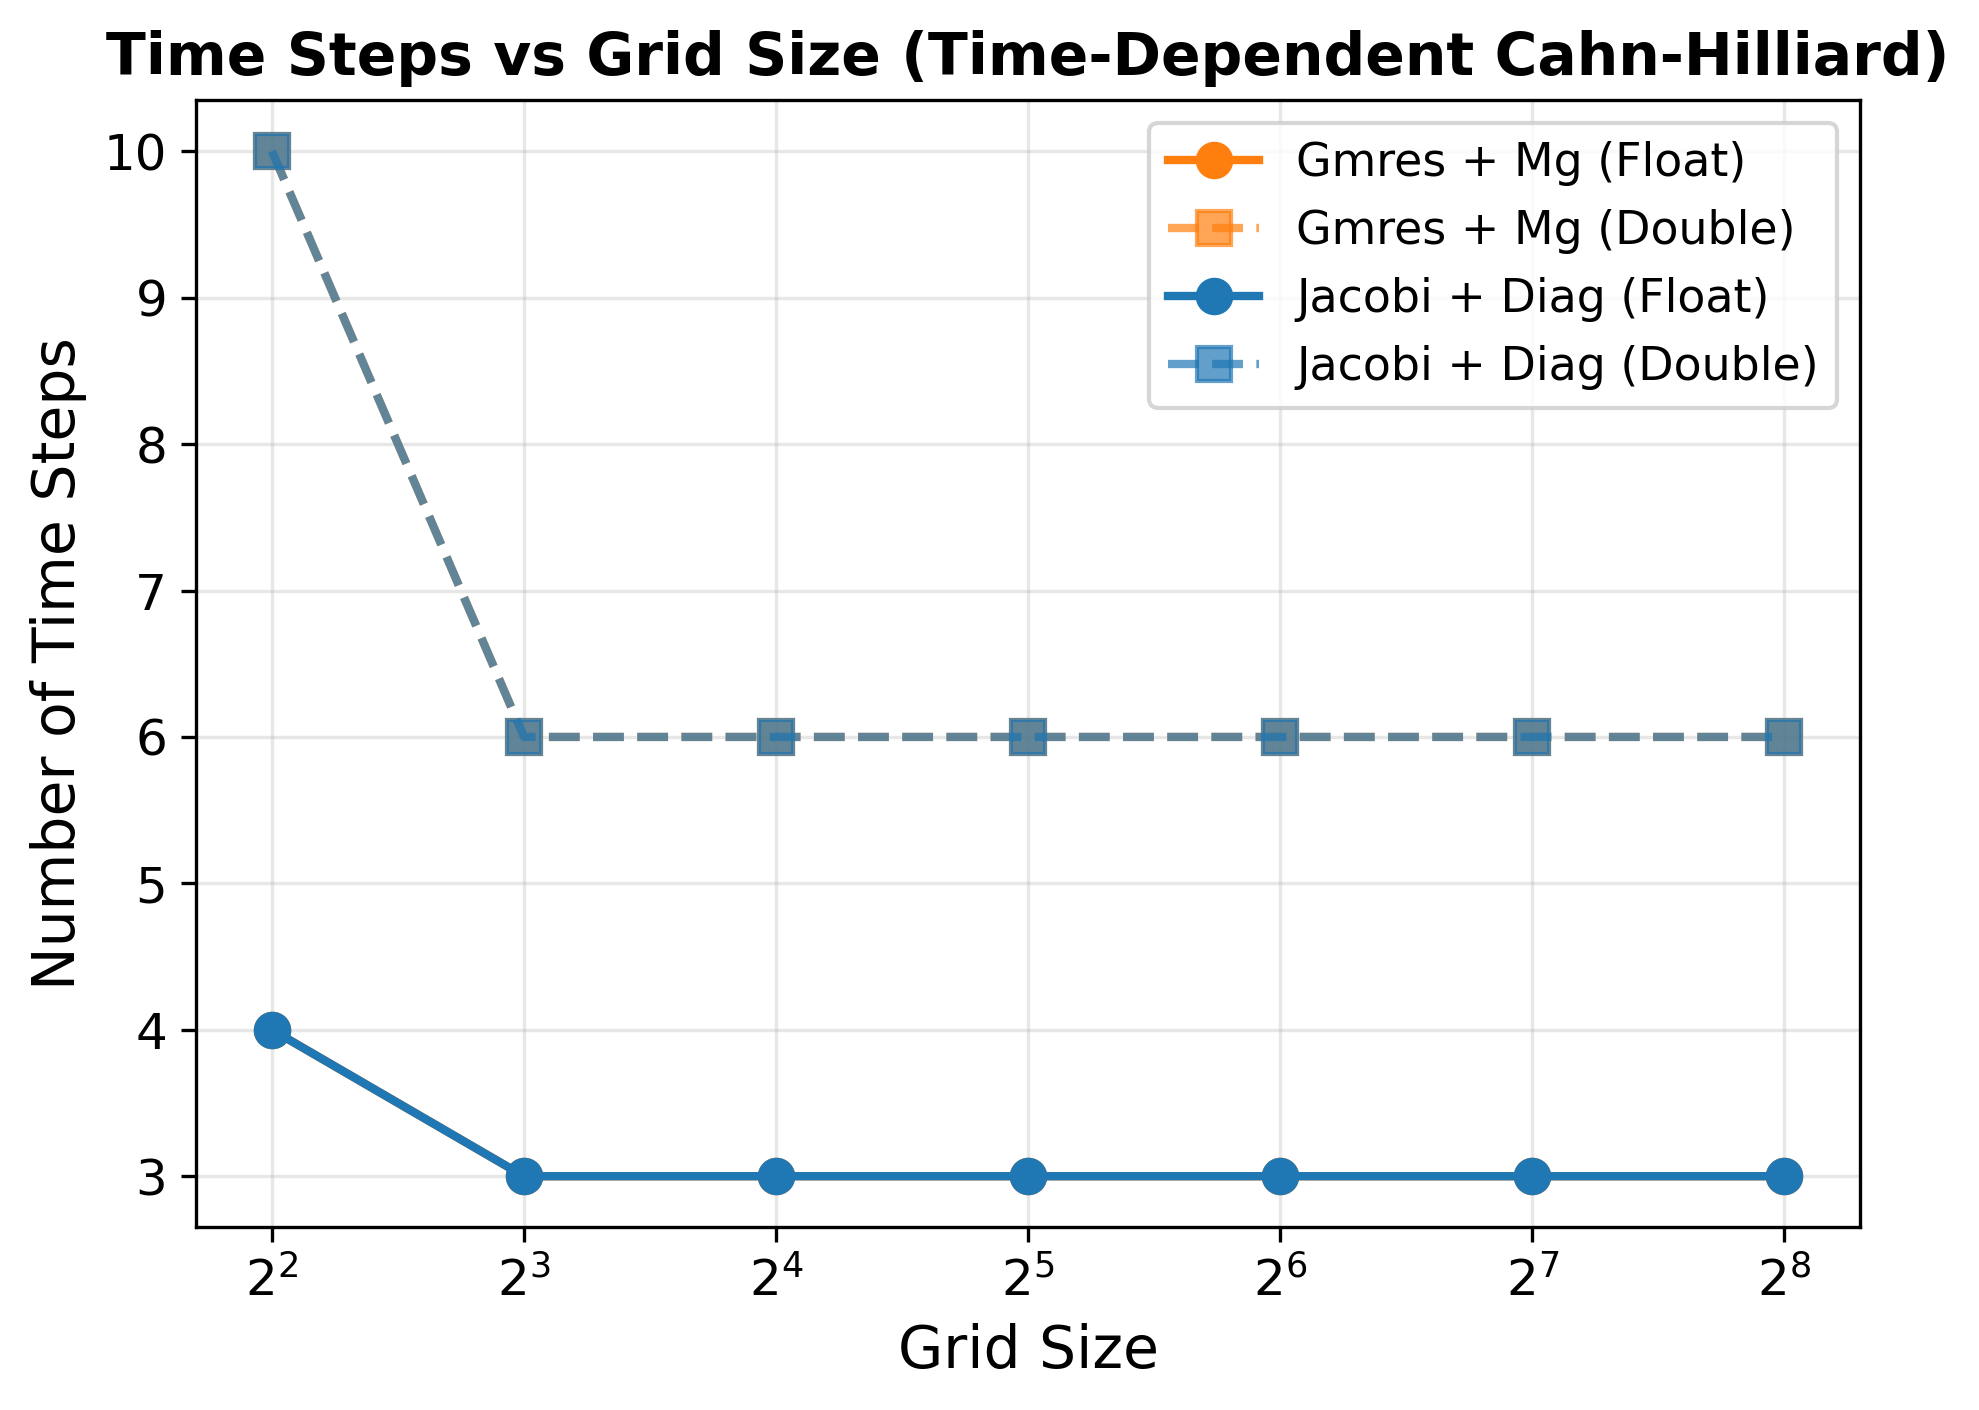

In [35]:
# Plot 1: Number of time steps vs grid size
scale = 0.8
fig, ax = plt.subplots(figsize=(8*scale, 6*scale), dpi=300)

# Prepare data for plotting: {solver_prec: {dtype: {grid_sizes, time_steps}}}
plot_data = {}

for solver_prec_key in sorted(time_cahn_hilliard_data.keys()):
    plot_data[solver_prec_key] = {
        'float': {'grid_sizes': [], 'time_steps': []},
        'double': {'grid_sizes': [], 'time_steps': []}
    }

    for grid_size in sorted(time_cahn_hilliard_data[solver_prec_key].keys()):
        if 'float' in time_cahn_hilliard_data[solver_prec_key][grid_size]:
            plot_data[solver_prec_key]['float']['grid_sizes'].append(grid_size)
            plot_data[solver_prec_key]['float']['time_steps'].append(
                time_cahn_hilliard_data[solver_prec_key][grid_size]['float']['time_steps'])

        if 'double' in time_cahn_hilliard_data[solver_prec_key][grid_size]:
            plot_data[solver_prec_key]['double']['grid_sizes'].append(grid_size)
            plot_data[solver_prec_key]['double']['time_steps'].append(
                time_cahn_hilliard_data[solver_prec_key][grid_size]['double']['time_steps'])

# Plot lines for each solver+prec combination
colors = {'jacobi_diag': '#1f77b4', 'gmres_mg': '#ff7f0e'}
markers = {'float': 'o', 'double': 's'}
linestyles = {'float': '-', 'double': '--'}

for solver_prec_key in sorted(plot_data.keys()):
    solver_prec_label = solver_prec_key.replace('_', ' + ').title()
    color = colors.get(solver_prec_key, '#2ca02c')

    # Plot float
    if plot_data[solver_prec_key]['float']['grid_sizes']:
        ax.plot(plot_data[solver_prec_key]['float']['grid_sizes'],
                plot_data[solver_prec_key]['float']['time_steps'],
                marker=markers['float'], linestyle=linestyles['float'],
                label=f'{solver_prec_label} (Float)', linewidth=2, markersize=8, color=color)

    # Plot double
    if plot_data[solver_prec_key]['double']['grid_sizes']:
        ax.plot(plot_data[solver_prec_key]['double']['grid_sizes'],
                plot_data[solver_prec_key]['double']['time_steps'],
                marker=markers['double'], linestyle=linestyles['double'],
                label=f'{solver_prec_label} (Double)', linewidth=2, markersize=8, color=color, alpha=0.7)

ax.set_xlabel('Grid Size', fontsize=14)
ax.set_ylabel('Number of Time Steps', fontsize=14)
ax.set_title('Time Steps vs Grid Size (Time-Dependent Cahn-Hilliard)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

# Set log scale on x-axis (base 2)
ax.set_xscale('log', base=2)
ax.set_yscale('linear')

# Format ticks
ax.tick_params(axis='both', which='major', labelsize=12)
ax.tick_params(axis='both', which='minor', labelsize=12)

plt.tight_layout()
plt.show()

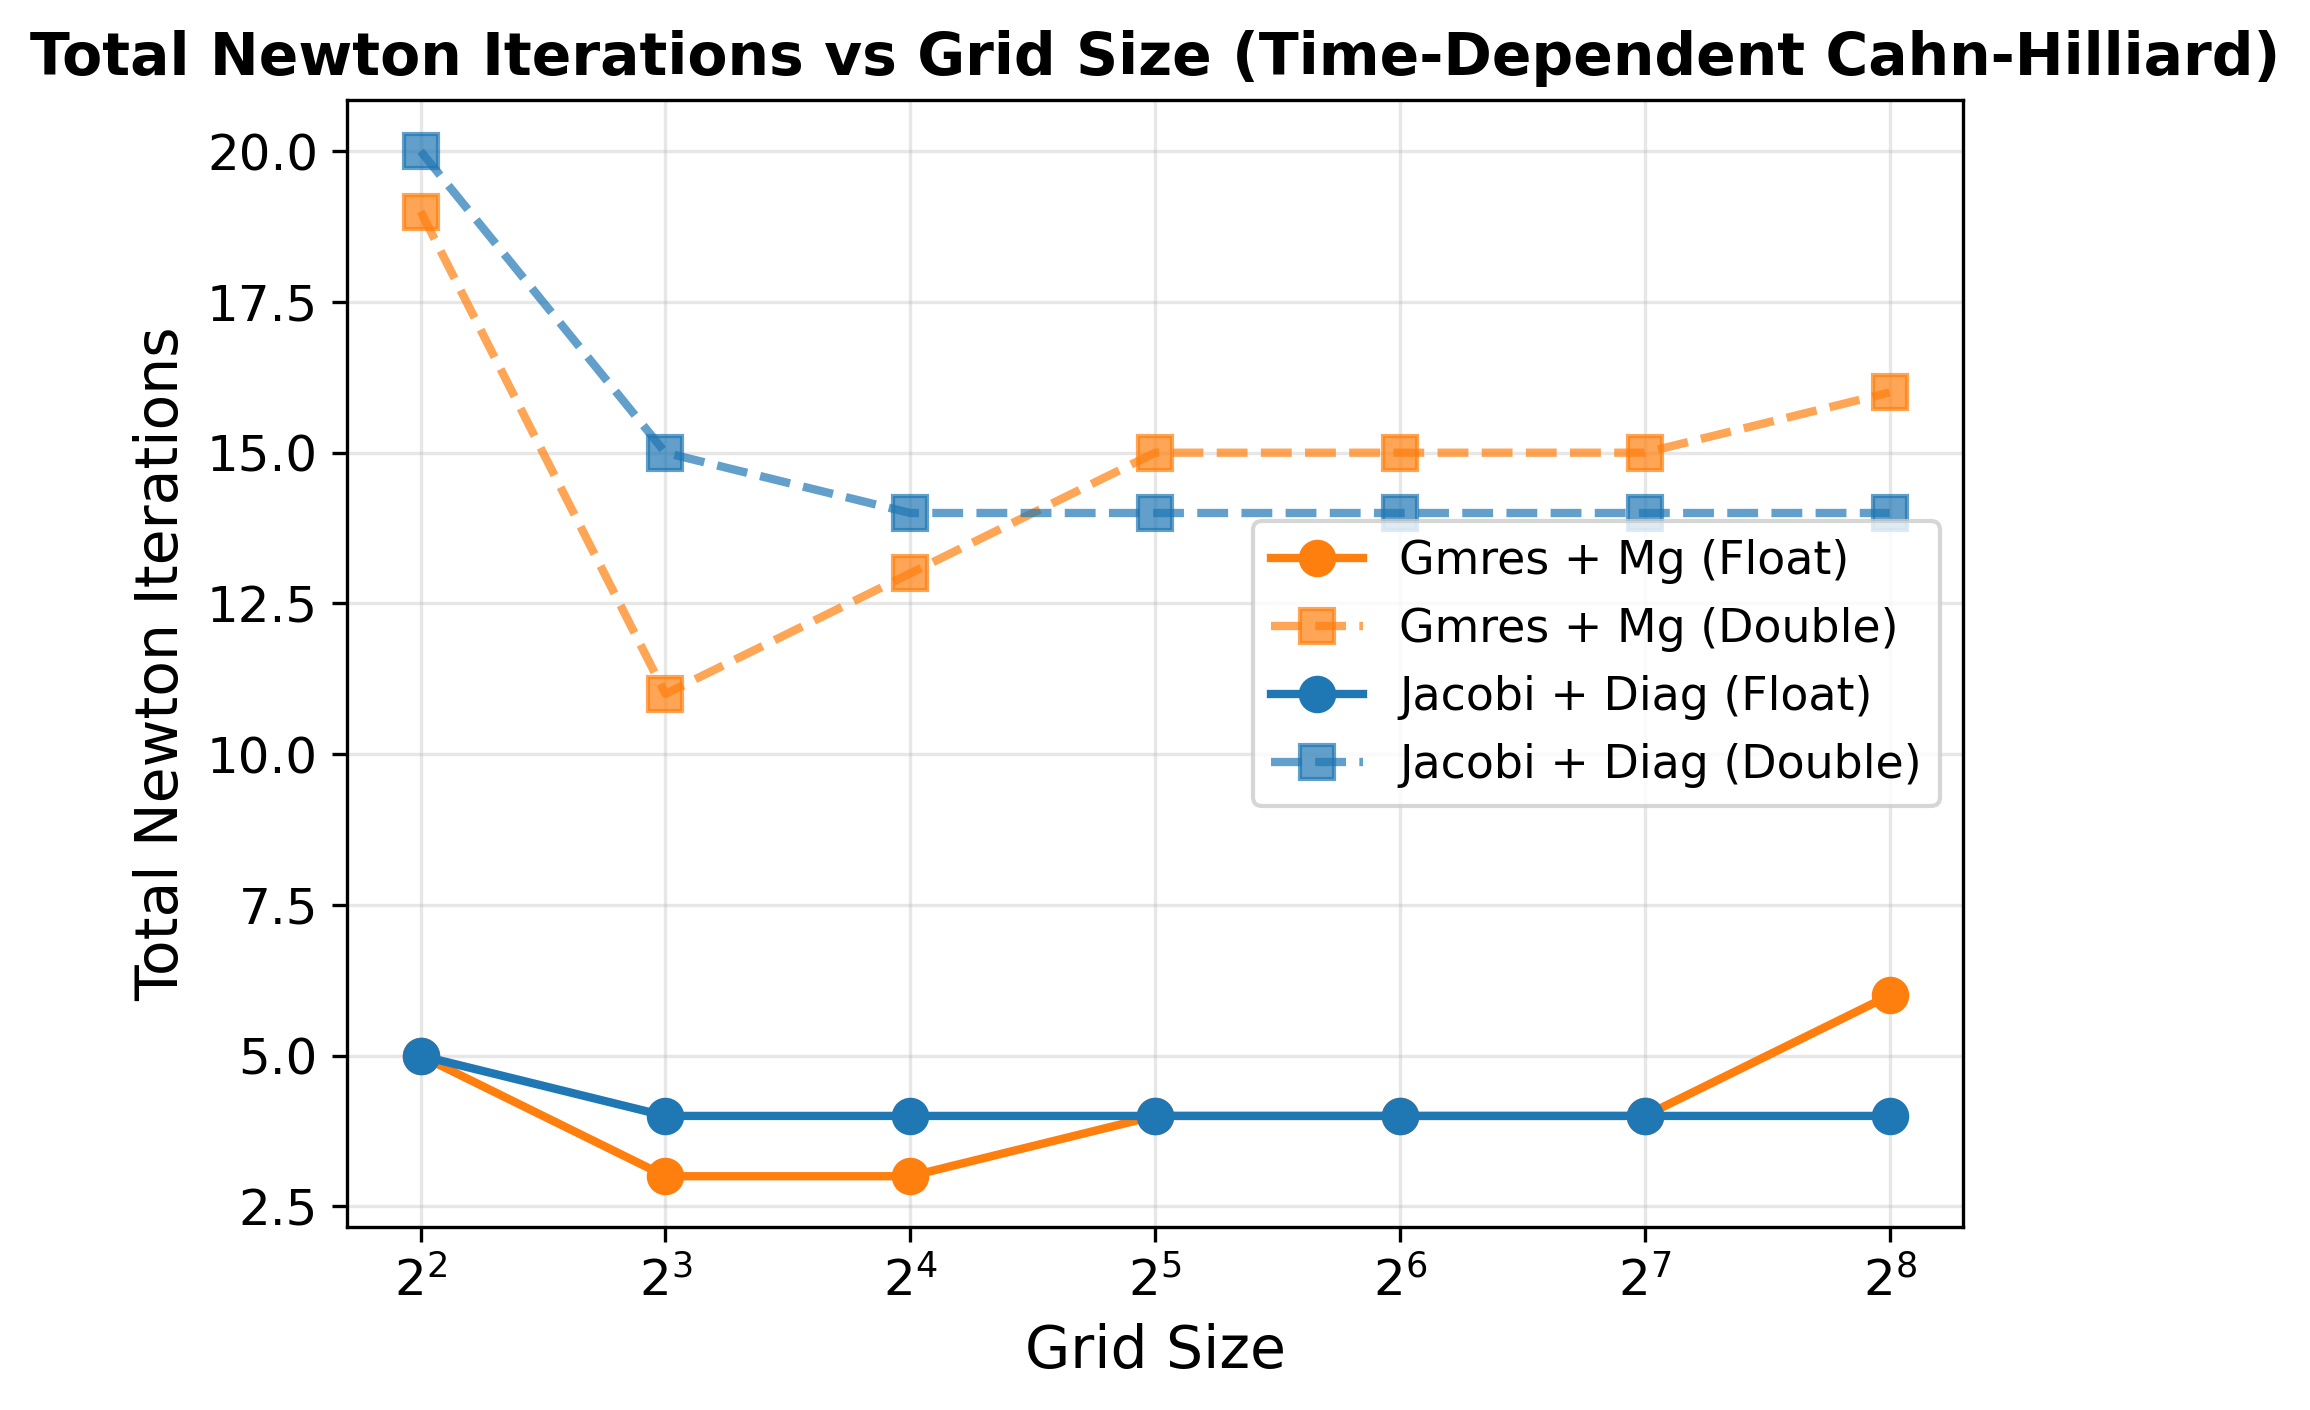

In [36]:
# Plot 2: Total Newton iterations vs grid size
scale = 0.8
fig, ax = plt.subplots(figsize=(8*scale, 6*scale), dpi=300)

# Prepare data for plotting
plot_data = {}

for solver_prec_key in sorted(time_cahn_hilliard_data.keys()):
    plot_data[solver_prec_key] = {
        'float': {'grid_sizes': [], 'newton_iters': []},
        'double': {'grid_sizes': [], 'newton_iters': []}
    }

    for grid_size in sorted(time_cahn_hilliard_data[solver_prec_key].keys()):
        if 'float' in time_cahn_hilliard_data[solver_prec_key][grid_size]:
            plot_data[solver_prec_key]['float']['grid_sizes'].append(grid_size)
            plot_data[solver_prec_key]['float']['newton_iters'].append(
                time_cahn_hilliard_data[solver_prec_key][grid_size]['float']['total_newton_iters'])

        if 'double' in time_cahn_hilliard_data[solver_prec_key][grid_size]:
            plot_data[solver_prec_key]['double']['grid_sizes'].append(grid_size)
            plot_data[solver_prec_key]['double']['newton_iters'].append(
                time_cahn_hilliard_data[solver_prec_key][grid_size]['double']['total_newton_iters'])

# Plot lines for each solver+prec combination
colors = {'jacobi_diag': '#1f77b4', 'gmres_mg': '#ff7f0e'}
markers = {'float': 'o', 'double': 's'}
linestyles = {'float': '-', 'double': '--'}

for solver_prec_key in sorted(plot_data.keys()):
    solver_prec_label = solver_prec_key.replace('_', ' + ').title()
    color = colors.get(solver_prec_key, '#2ca02c')

    # Plot float
    if plot_data[solver_prec_key]['float']['grid_sizes']:
        ax.plot(plot_data[solver_prec_key]['float']['grid_sizes'],
                plot_data[solver_prec_key]['float']['newton_iters'],
                marker=markers['float'], linestyle=linestyles['float'],
                label=f'{solver_prec_label} (Float)', linewidth=2, markersize=8, color=color)

    # Plot double
    if plot_data[solver_prec_key]['double']['grid_sizes']:
        ax.plot(plot_data[solver_prec_key]['double']['grid_sizes'],
                plot_data[solver_prec_key]['double']['newton_iters'],
                marker=markers['double'], linestyle=linestyles['double'],
                label=f'{solver_prec_label} (Double)', linewidth=2, markersize=8, color=color, alpha=0.7)

ax.set_xlabel('Grid Size', fontsize=14)
ax.set_ylabel('Total Newton Iterations', fontsize=14)
ax.set_title('Total Newton Iterations vs Grid Size (Time-Dependent Cahn-Hilliard)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

# Set log scale on x-axis (base 2)
ax.set_xscale('log', base=2)
ax.set_yscale('linear')

# Format ticks
ax.tick_params(axis='both', which='major', labelsize=12)
ax.tick_params(axis='both', which='minor', labelsize=12)

plt.tight_layout()
plt.show()

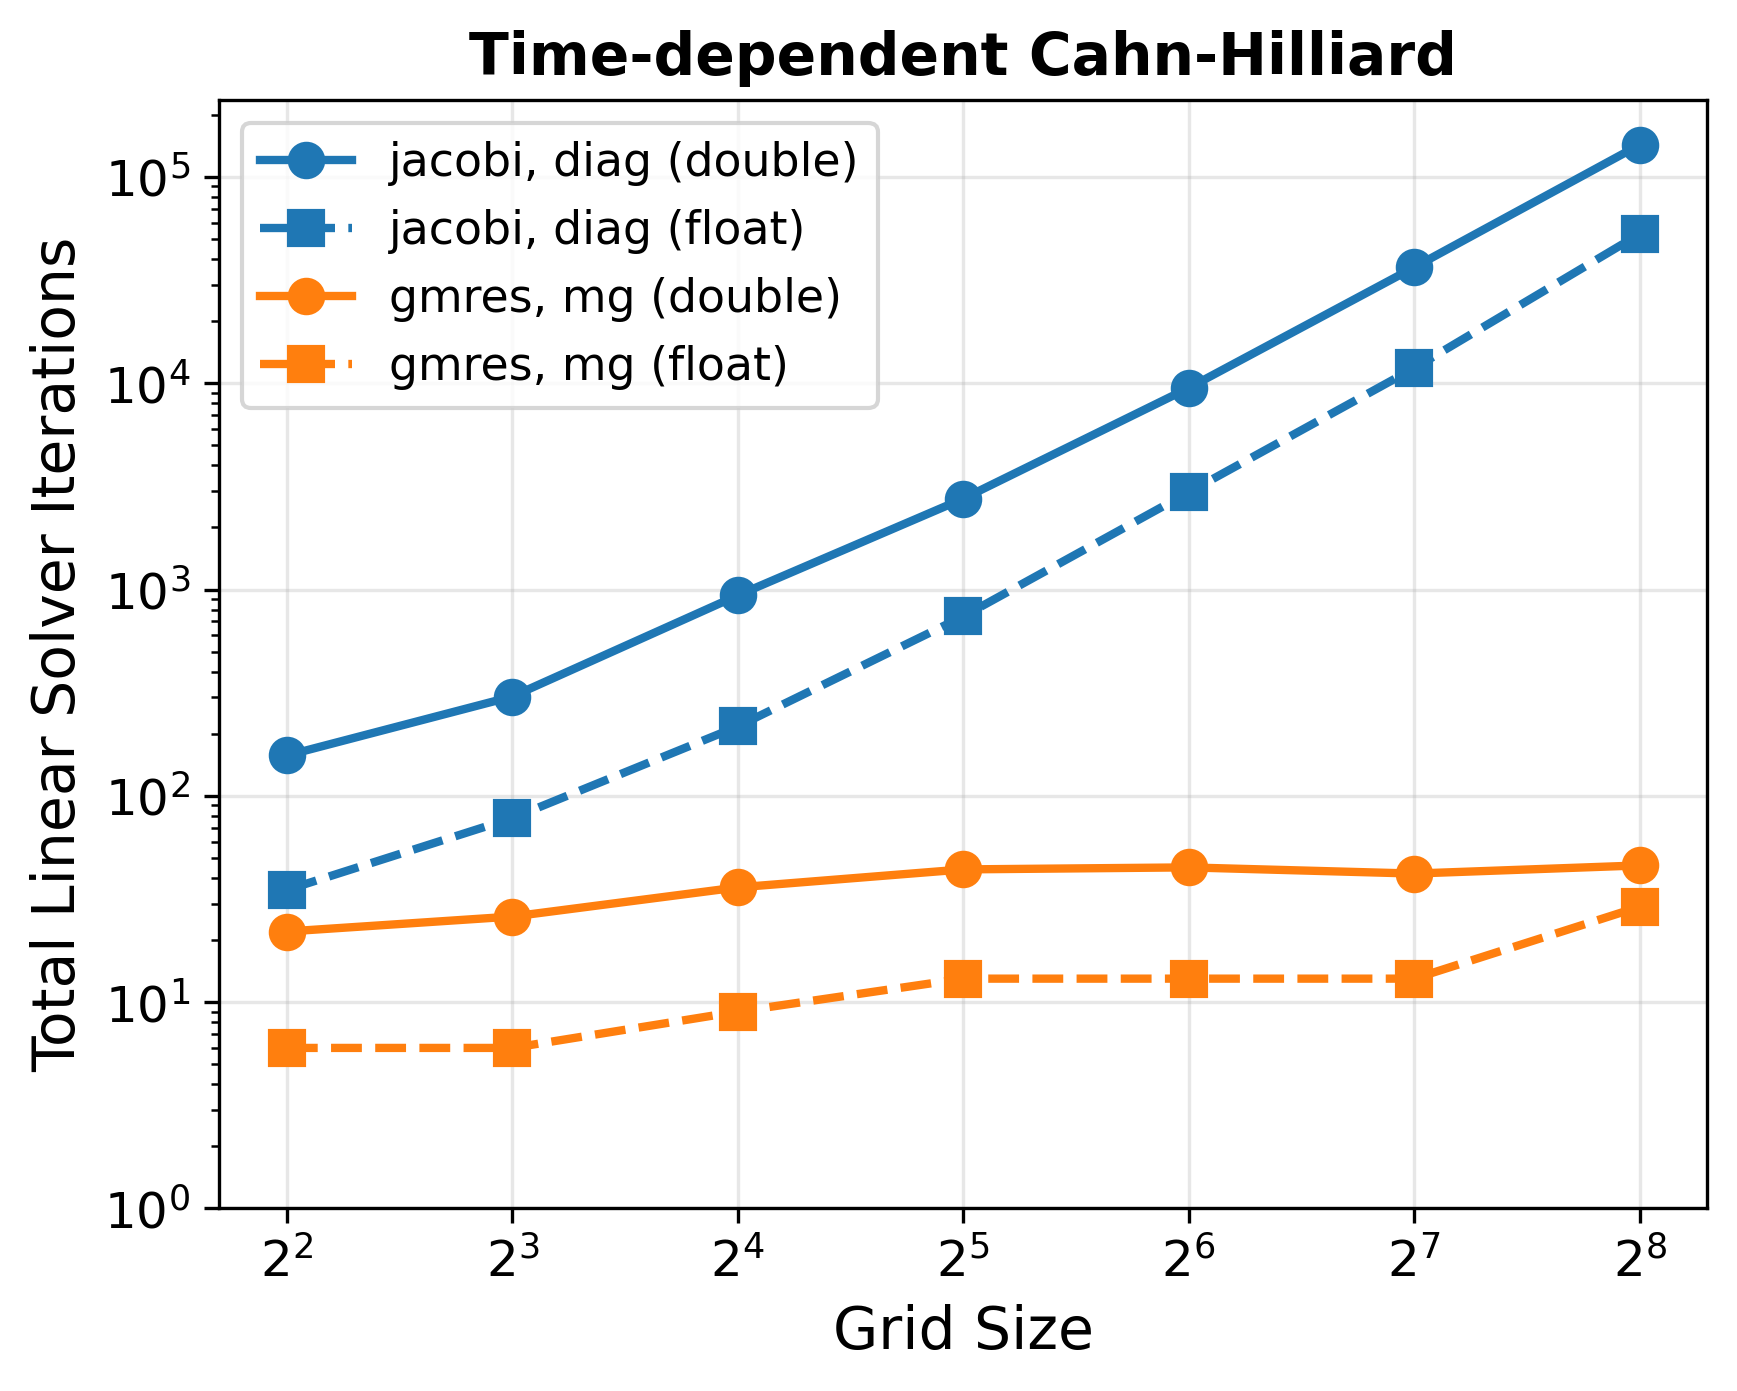

In [37]:
# Plot 3: Total linear solver iterations vs grid size
scale = 0.8
fig, ax = plt.subplots(figsize=(8*scale, 6*scale), dpi=300)

# Prepare data for plotting
plot_data = {}

for solver_prec_key in sorted(time_cahn_hilliard_data.keys()):
    plot_data[solver_prec_key] = {
        'float': {'grid_sizes': [], 'linear_iters': []},
        'double': {'grid_sizes': [], 'linear_iters': []}
    }

    for grid_size in sorted(time_cahn_hilliard_data[solver_prec_key].keys()):
        if 'float' in time_cahn_hilliard_data[solver_prec_key][grid_size]:
            plot_data[solver_prec_key]['float']['grid_sizes'].append(grid_size)
            plot_data[solver_prec_key]['float']['linear_iters'].append(
                time_cahn_hilliard_data[solver_prec_key][grid_size]['float']['total_linear_iters'])

        if 'double' in time_cahn_hilliard_data[solver_prec_key][grid_size]:
            plot_data[solver_prec_key]['double']['grid_sizes'].append(grid_size)
            plot_data[solver_prec_key]['double']['linear_iters'].append(
                time_cahn_hilliard_data[solver_prec_key][grid_size]['double']['total_linear_iters'])

# Plot lines for each solver+prec combination
colors = {'jacobi_diag': '#1f77b4', 'gmres_mg': '#ff7f0e'}
markers = {'float': 's', 'double': 'o'}
linestyles = {'float': '--', 'double': '-'}

solver_prec_order = ['jacobi_diag', 'gmres_mg']
for solver_prec_key in solver_prec_order:
    solver_prec_label = solver_prec_key.replace('_', ', ')
    color = colors.get(solver_prec_key, '#2ca02c')

    # Plot double
    if plot_data[solver_prec_key]['double']['grid_sizes']:
        ax.plot(plot_data[solver_prec_key]['double']['grid_sizes'],
                plot_data[solver_prec_key]['double']['linear_iters'],
                marker=markers['double'], linestyle=linestyles['double'],
                label=f'{solver_prec_label} (double)', linewidth=2, markersize=8, color=color)


    # Plot float
    if plot_data[solver_prec_key]['float']['grid_sizes']:
        ax.plot(plot_data[solver_prec_key]['float']['grid_sizes'],
                plot_data[solver_prec_key]['float']['linear_iters'],
                marker=markers['float'], linestyle=linestyles['float'],
                label=f'{solver_prec_label} (float)', linewidth=2, markersize=8, color=color)

ax.set_xlabel('Grid Size', fontsize=14)
ax.set_ylabel('Total Linear Solver Iterations', fontsize=14)
ax.set_title('Time-dependent Cahn-Hilliard', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

# Set log scale on x-axis (base 2)
ax.set_xscale('log', base=2)
ax.set_yscale('log', base=10)

# Format ticks
ax.tick_params(axis='both', which='major', labelsize=12)
ax.tick_params(axis='both', which='minor', labelsize=12)

y_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5]
ax.set_yticks(y_ticks)
ax.set_yticklabels([f'$10^{{{int(np.log10(t))}}}$' for t in y_ticks], fontsize=12)

# plt.tight_layout()
plt.show()

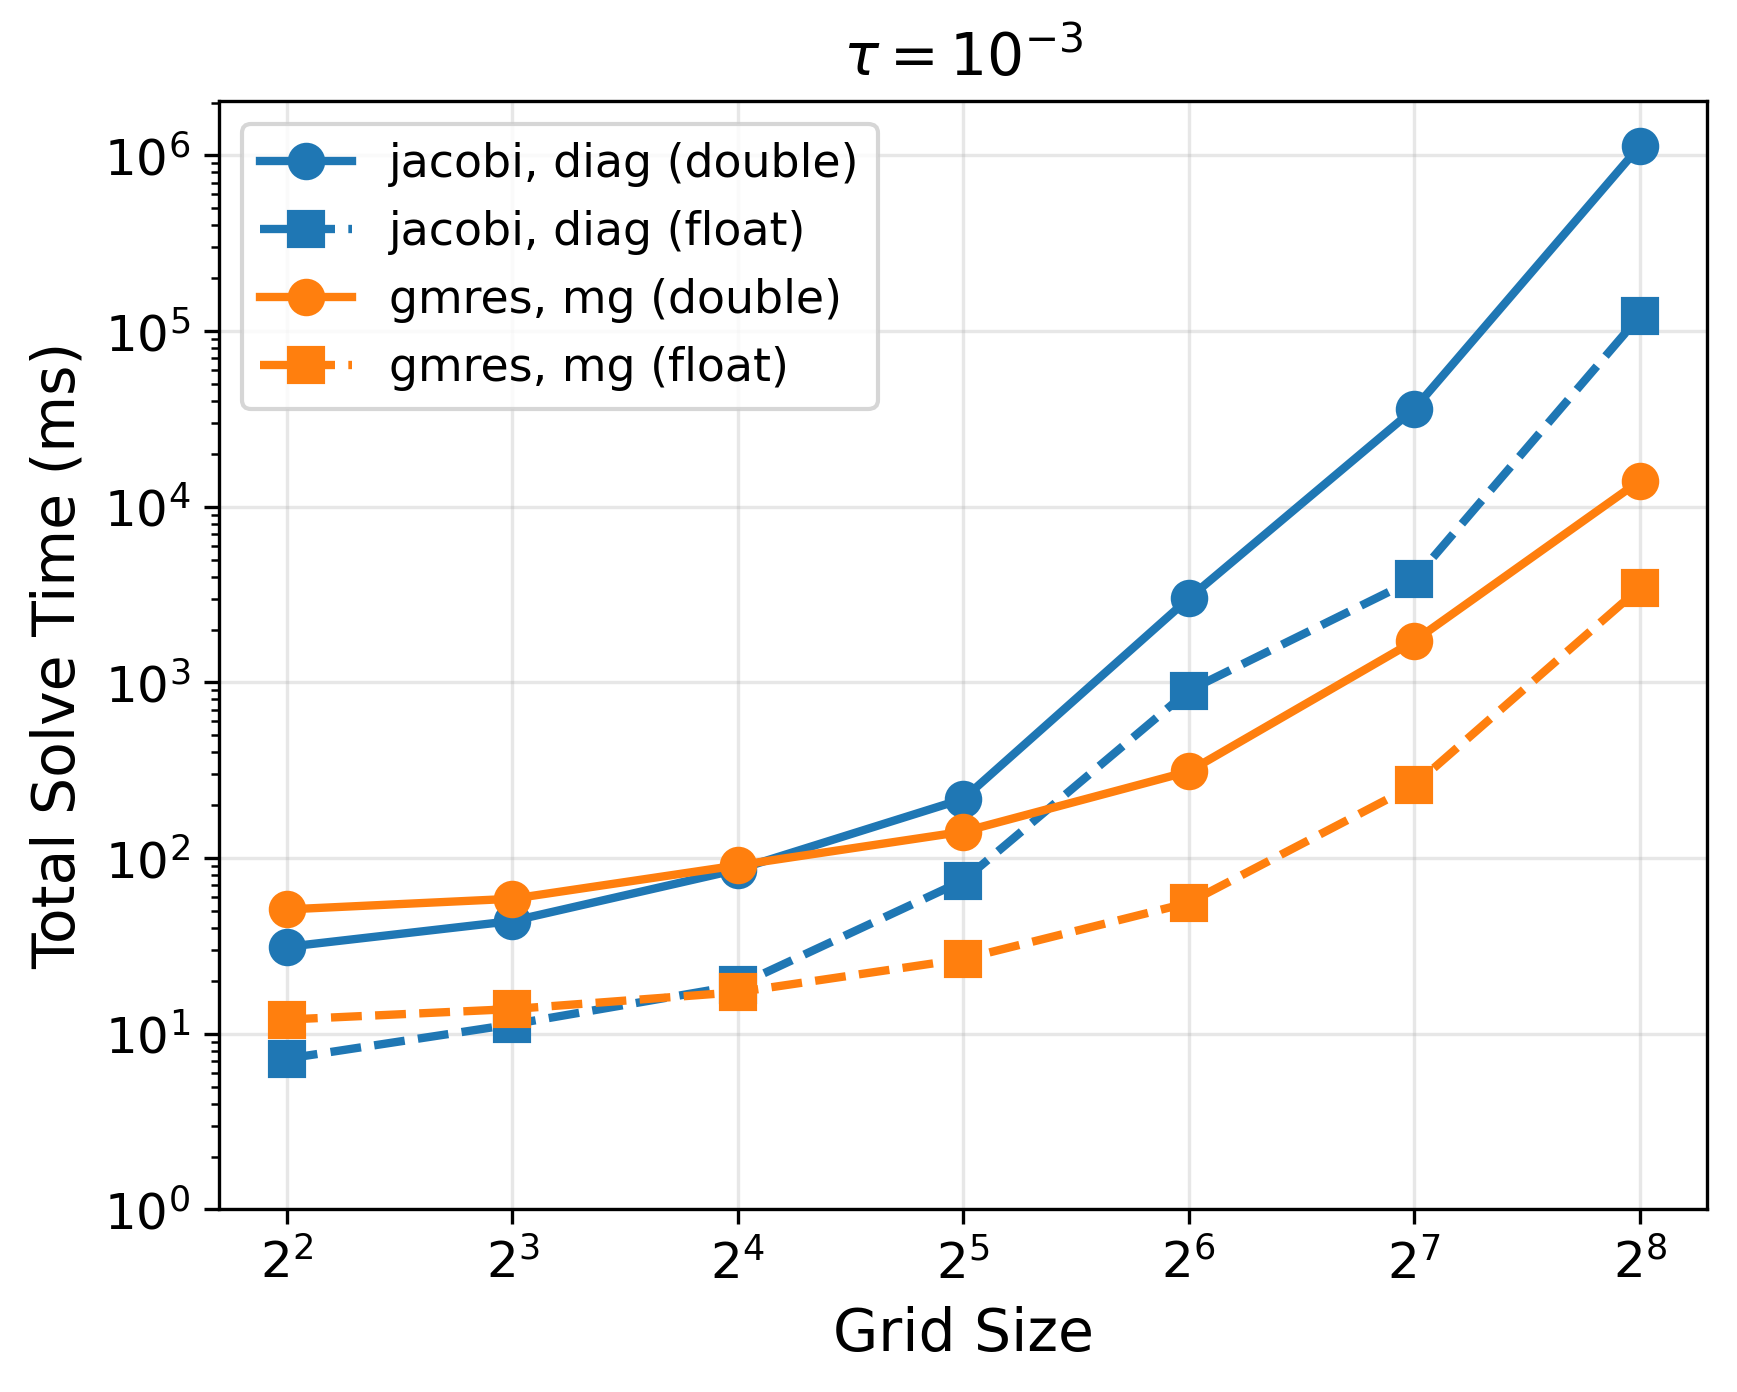

In [39]:
# Plot 4: Wall time (total solve time) vs grid size
scale = 0.8
fig, ax = plt.subplots(figsize=(8*scale, 6*scale), dpi=300)

# Prepare data for plotting
plot_data = {}

for solver_prec_key in sorted(time_cahn_hilliard_data.keys()):
    plot_data[solver_prec_key] = {
        'float': {'grid_sizes': [], 'solve_times': []},
        'double': {'grid_sizes': [], 'solve_times': []}
    }

    for grid_size in sorted(time_cahn_hilliard_data[solver_prec_key].keys()):
        if 'float' in time_cahn_hilliard_data[solver_prec_key][grid_size]:
            solve_time = time_cahn_hilliard_data[solver_prec_key][grid_size]['float'].get('total_solve_time_ms')
            if solve_time is not None:
                plot_data[solver_prec_key]['float']['grid_sizes'].append(grid_size)
                plot_data[solver_prec_key]['float']['solve_times'].append(solve_time)

        if 'double' in time_cahn_hilliard_data[solver_prec_key][grid_size]:
            solve_time = time_cahn_hilliard_data[solver_prec_key][grid_size]['double'].get('total_solve_time_ms')
            if solve_time is not None:
                plot_data[solver_prec_key]['double']['grid_sizes'].append(grid_size)
                plot_data[solver_prec_key]['double']['solve_times'].append(solve_time)

# Plot lines for each solver+prec combination
colors = {'jacobi_diag': '#1f77b4', 'gmres_mg': '#ff7f0e'}
markers = {'float': 's', 'double': 'o'}
linestyles = {'float': '--', 'double': '-'}

solver_prec_order = ['jacobi_diag', 'gmres_mg']
for solver_prec_key in solver_prec_order:
    if solver_prec_key not in plot_data:
        continue
    solver_prec_label = solver_prec_key.replace('_', ', ')
    color = colors.get(solver_prec_key, '#2ca02c')

    # Plot double
    if plot_data[solver_prec_key]['double']['grid_sizes']:
        ax.plot(plot_data[solver_prec_key]['double']['grid_sizes'],
                plot_data[solver_prec_key]['double']['solve_times'],
                marker=markers['double'], linestyle=linestyles['double'],
                label=f'{solver_prec_label} (double)', linewidth=2, markersize=8, color=color)

    # Plot float
    if plot_data[solver_prec_key]['float']['grid_sizes']:
        ax.plot(plot_data[solver_prec_key]['float']['grid_sizes'],
                plot_data[solver_prec_key]['float']['solve_times'],
                marker=markers['float'], linestyle=linestyles['float'],
                label=f'{solver_prec_label} (float)', linewidth=2, markersize=8, color=color)

ax.set_xlabel('Grid Size', fontsize=14)
ax.set_ylabel('Total Solve Time (ms)', fontsize=14)
ax.set_title(r'$\tau=10^{-3}$', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

# Set log scale on x-axis (base 2)
ax.set_xscale('log', base=2)
ax.set_yscale('log', base=10)

# Format ticks
ax.tick_params(axis='both', which='major', labelsize=12)
ax.tick_params(axis='both', which='minor', labelsize=12)

y_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.set_yticks(y_ticks)
ax.set_yticklabels([f'$10^{{{int(np.log10(t))}}}$' for t in y_ticks], fontsize=12)

# plt.tight_layout()
plt.show()

---

## Time-Dependent Cahn-Hilliard Solution Visualization

Found 87661 solution files in data/ch_128_100k_5e5_20260126_112055
Loading frame 87660: numerical_87661.bin
Loaded solution with grid size N = 128


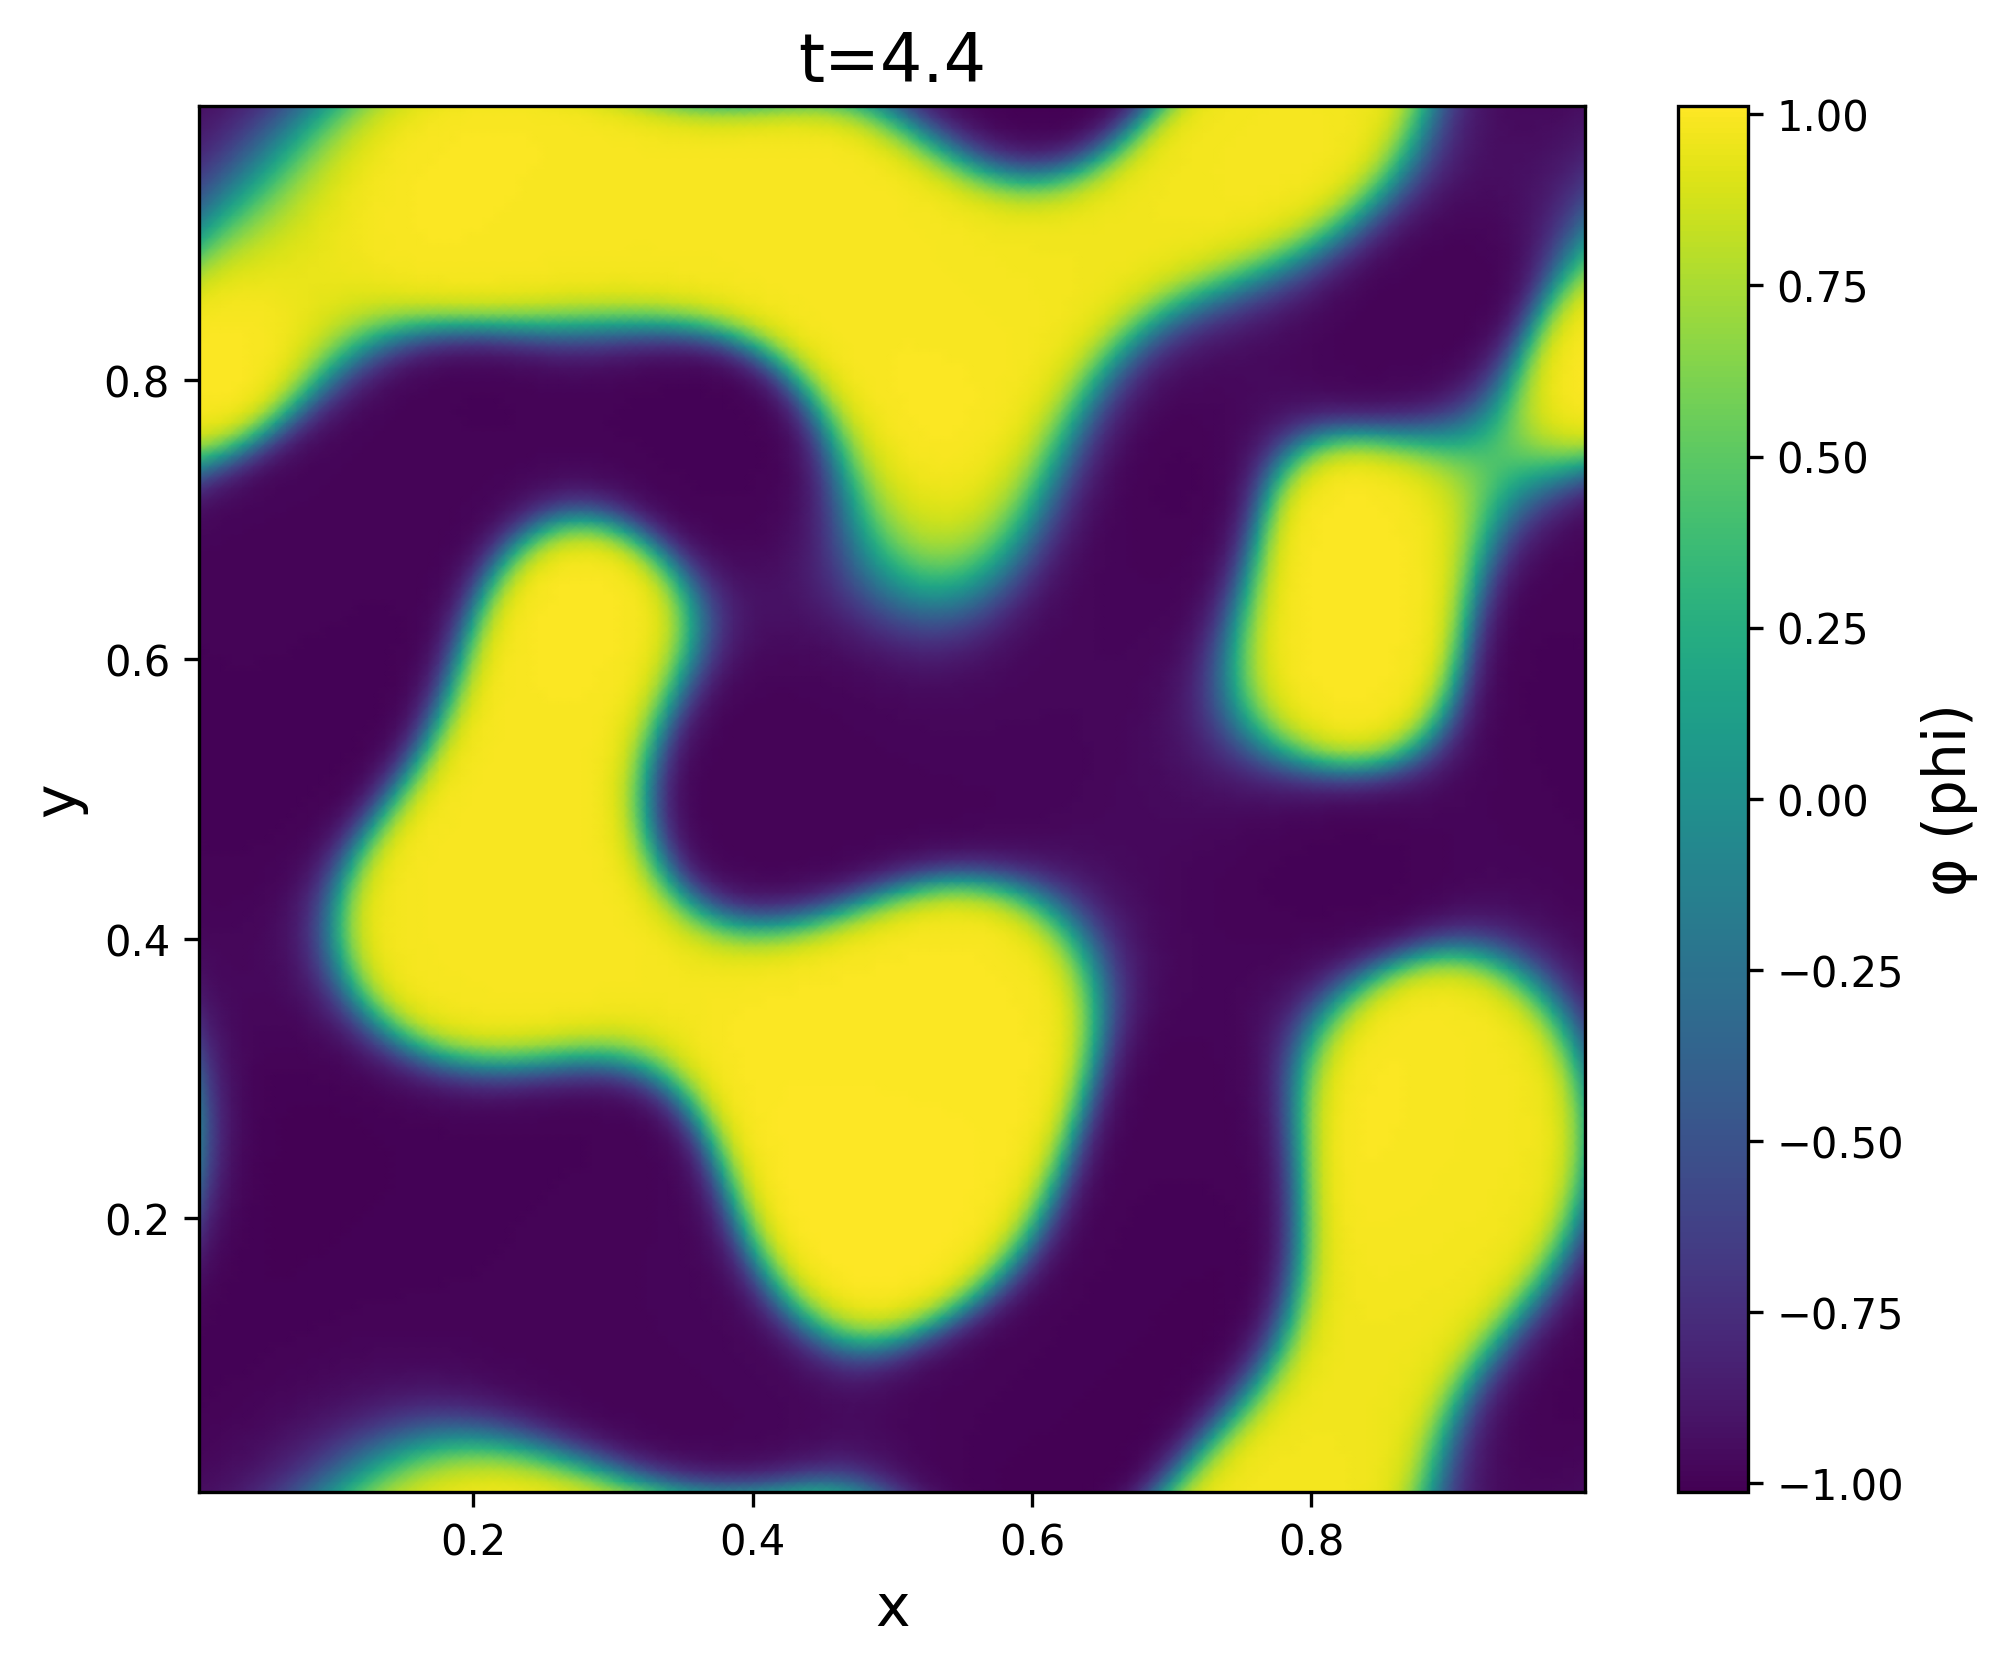

In [61]:
# 2D Slice Visualization for Time-Dependent Cahn-Hilliard Solution


def load_solution(filename):
    """Load solution from binary file saved by C++ code."""
    with open(filename, 'rb') as f:
        dims = np.frombuffer(f.read(12), dtype=np.int32)
        n_components = np.frombuffer(f.read(4), dtype=np.int32)[0]
        data = np.frombuffer(f.read(), dtype=np.float64)
        data = data.reshape((dims[2], dims[1], dims[0], n_components))
        # Transpose to (N, N, N, 2) with x as first axis
        data = np.transpose(data, (2, 1, 0, 3))
    return data, dims[0]

# ============================================================
# PARAMETERS - Modify these to visualize different solutions
# ============================================================

# Path to the folder containing numerical_*.bin files
# Example: "data/conv_time_cahn_hilliard_grid_prod/64/gmres_mg_cuda_double_64_20260201_000605"
folder_path = "data/ch_128_100k_5e5_20260126_112055"

# Frame number to visualize (0 = initial approximation, 1+ = after time steps)
# frame_number = 0
# frame_number = 2000
frame_number = 87660

# Slice axis: 0=x, 1=y, 2=z (axis perpendicular to the slice plane)
slice_axis = 2  # z-axis (shows x-y plane)

# Layer index along the slice axis (0 to N-1)
layer_idx = 32  # Middle layer (adjust based on grid size)

# Component: 0=psi (ψ), 1=phi (φ)
component = 1  # phi

# ============================================================
# Visualization code
# ============================================================

# Find numerical solution files
numerical_files = sorted(glob.glob(str(Path(folder_path) / 'numerical_*.bin')),
                        key=lambda x: int(x.split('_')[-1].split('.')[0]))

if len(numerical_files) == 0:
    print(f"Error: No numerical solution files found in {folder_path}")
    print("Please check the folder_path parameter.")
else:
    print(f"Found {len(numerical_files)} solution files in {folder_path}")

    if frame_number >= len(numerical_files):
        print(f"Error: frame_number {frame_number} is out of range. Max: {len(numerical_files) - 1}")
    else:
        # Load the selected frame
        filename = numerical_files[frame_number]
        print(f"Loading frame {frame_number}: {Path(filename).name}")

        try:
            data, N = load_solution(filename)
            print(f"Loaded solution with grid size N = {N}")

            # Validate layer index
            if layer_idx < 0 or layer_idx >= N:
                print(f"Error: layer_idx {layer_idx} is out of range [0, {N-1}]")
                print(f"Setting layer_idx to {N//2} (middle layer)")
                layer_idx = N // 2

            # Calculate cell-centered coordinate values: h*(0.5 + i) for i = 0, 1, ..., N-1
            h = 1.0 / N
            cell_centered_coords = np.array([h * (0.5 + i) for i in range(N)])

            # Map axis name to index
            axis_names = ['x', 'y', 'z']
            component_names = ['ψ (psi)', 'φ (phi)']

            # Extract 2D slice based on slice_axis and layer_idx
            if slice_axis == 0:  # Slice along x-axis: show y-z plane
                slice_data = data[layer_idx, :, :, component]
                x_coords = cell_centered_coords  # y coordinates
                y_coords = cell_centered_coords  # z coordinates
                xlabel = 'y'
                ylabel = 'z'
                title_axis = f'x = {cell_centered_coords[layer_idx]:.4f}'
            elif slice_axis == 1:  # Slice along y-axis: show x-z plane
                slice_data = data[:, layer_idx, :, component]
                x_coords = cell_centered_coords  # x coordinates
                y_coords = cell_centered_coords  # z coordinates
                xlabel = 'x'
                ylabel = 'z'
                title_axis = f'y = {cell_centered_coords[layer_idx]:.4f}'
            else:  # slice_axis == 2, Slice along z-axis: show x-y plane
                slice_data = data[:, :, layer_idx, component]
                x_coords = cell_centered_coords  # x coordinates
                y_coords = cell_centered_coords  # y coordinates
                xlabel = 'x'
                ylabel = 'y'
                title_axis = f'z = {cell_centered_coords[layer_idx]:.4f}'

            # Create meshgrid for plotting
            X, Y = np.meshgrid(x_coords, y_coords, indexing='ij')

            # Create figure
            fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

            # Create heatmap with automatic scaling (same style as animate_solution.py)
            im = ax.pcolormesh(X, Y, slice_data,
                              cmap='viridis',
                              shading='gouraud')

            # Add colorbar
            cbar = plt.colorbar(im, ax=ax)
            cbar.set_label(component_names[component], fontsize=14)

            ax.set_xlabel(xlabel, fontsize=14)
            ax.set_ylabel(ylabel, fontsize=14)

            # Title
            # title = f'Cahn-Hilliard: {component_names[component]} slice at {title_axis}'
            # if frame_number == 0:
            #     title += ', Initial approximation'
            # else:
            #     title += f', After time step {frame_number}'
            # title += f' (N={N})'
            title=f't={5e-5*frame_number:.1f}'
            ax.set_title(title, fontsize=16)

            ax.set_aspect('equal')
            # plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"Error loading solution file {filename}: {e}")
            import traceback
            traceback.print_exc()